<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# EDA — Fashion MNIST (TP4A)
<!-- EDA_FASHION_MNIST -->

**Modo A:** EDA previo al preprocesamiento. Se trabaja sobre los datos crudos (`X_train`, `y_train`, `X_test`, `y_test`) sin modificarlos: cuando un análisis necesita escalar o aplanar, lo hace sobre copias con prefijo `eda_`.

Cada análisis responde una pregunta que hay que contestar en los ejercicios del TP:

| Ejercicio | Qué necesita saber del dato |
|---|---|
| 1.1 Random Forest + matriz de confusión | ¿Qué clases se parecen entre sí? ¿Están balanceadas? |
| 1.2 RF binario + ROC/AUC | ¿Qué par de clases conviene elegir (fácil vs. difícil)? |
| 2 Optuna sobre RF | ¿Cuántas features aportan información? ¿Cuánto cuesta cada trial? |
| 3 MLP con poda | ¿Qué escala necesitan los píxeles? ¿Hay diferencias train/test? |

**Heurísticas declaradas:** n = 70.000 > 50.000 → los gráficos de dispersión y t-SNE/UMAP usan una muestra estratificada con `random_state=42`. Variables > 8 (784 píxeles) → sin pairplot: se usa PCA. Ninguna etiqueta es un identificador (10 clases).

 0. Imports y funciones auxiliares
`estilizar` y `mostrar_lado_a_lado` son las mismas definidas en el notebook del TP1 (mismo nombre y firma).

In [2]:
# !pip install umap-learn   # descomentar si UMAP no esta instalado (Colab)
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import umap

SEMILLA = 42

NOMBRES_CLASES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Misma clase, mismo color en todos los graficos del analisis
PALETA_CLASES = sns.color_palette('tab10', 10)


def estilizar(df, cmap='Blues', precision=2):
  #Codifica una tabla con color en vez de imprimirla como texto plano (heatmap-style, por columna).
  #Ademas de background_gradient, se agregan estilos de tabla explicitos: al extraer el
  #HTML con .to_html() para mostrarlo dentro de un <div> propio (mostrar_lado_a_lado),
  #se pierde el CSS por default que Colab/Jupyter le pone a un DataFrame (padding, bordes,
  #tipografia) - sin esto se ve mas apretado/plano que una tabla mostrada normalmente.
  estilos_tabla = [
      {'selector': 'th', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de'), ('background-color', '#f6f8fa')]},
      {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de')]},
      {'selector': ''  , 'props': [('border-collapse', 'collapse'), ('font-size', '13px')]},
  ]
  return (
      df.style
      .background_gradient(cmap=cmap, axis=0)
      .format(precision=precision)
      .set_table_styles(estilos_tabla)
  )

def mostrar_lado_a_lado(tablas, cmap='Blues', precision=2):
  #Muestra varias tablas en una fila horizontal (en vez de apiladas) para que entren juntas en pantalla.
  #Cada tabla queda dentro de una tarjeta con borde propio, con mas separacion entre ellas
  #y entre el titulo y la tabla, para que se vea prolijo en vez de amontonado.
  bloques = []
  for titulo, df in tablas:
    bloques.append(
        "<div style='margin:0 32px 20px 0; padding:12px 14px; "
        "border:1px solid #d0d7de; border-radius:10px;'>"
        f"<div style='font-weight:600; margin-bottom:8px;'>{titulo}</div>"
        f"{estilizar(df, cmap=cmap, precision=precision).to_html()}</div>"
    )
  display(HTML("<div style='display:flex; flex-wrap:wrap;'>" + ''.join(bloques) + "</div>"))


def mostrar_tabla_texto(df):
    # Tabla de texto (sin gradiente): estilizar() aplica un gradiente numerico por columna
    # y aqui las celdas son frases, no numeros.
    estilos = [
        {'selector': 'th', 'props': [('padding', '6px 12px'), ('text-align', 'left'), ('border', '1px solid #d0d7de'), ('background-color', '#f6f8fa')]},
        {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'left'), ('border', '1px solid #d0d7de')]},
        {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-size', '13px')]},
    ]
    display(df.style.hide(axis='index').set_table_styles(estilos))


def muestra_estratificada(y, n_por_clase, semilla=SEMILLA):
    # Muestra con la misma cantidad por clase: con clases balanceadas es equivalente
    # a estratificar por proporcion, y garantiza que ninguna clase quede sub-representada.
    rng = np.random.default_rng(semilla)
    indices = [rng.choice(np.where(y == c)[0], n_por_clase, replace=False) for c in np.unique(y)]
    return np.sort(np.concatenate(indices))


def grilla_imagenes(imagenes, titulos, filas, columnas, titulo_general, cmap='gray',
                    vmin=None, vmax=None, colorbar_label=None):
    # Una sola figura para todas las imagenes; vmin/vmax compartidos para que los
    # colores sean comparables entre paneles (si no, cada panel se auto-escala).
    fig, ejes = plt.subplots(filas, columnas, figsize=(columnas * 2.6, filas * 2.9))
    for ax, img, tit in zip(ejes.ravel(), imagenes, titulos):
        im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(tit, fontsize=10)
        ax.axis('off')
    fig.suptitle(titulo_general, fontsize=13)
    if colorbar_label is not None:
        fig.colorbar(im, ax=ejes.ravel().tolist(), shrink=0.7, label=colorbar_label)
    else:
        plt.tight_layout()
    plt.show()


def heatmap_triangular(matriz, titulo, ax, cmap, fmt='.2f', centro=None):
    # Matriz simetrica: solo triangulo inferior y sin diagonal (la diagonal es
    # constante y no informa). Al quitar la diagonal, la primera fila y la ultima
    # columna quedan vacias, asi que se recortan para no dejar un panel en blanco.
    recorte = matriz[1:, :-1]
    mascara = np.triu(np.ones_like(recorte, dtype=bool), k=1)
    sns.heatmap(recorte, mask=mascara, annot=True, fmt=fmt, cmap=cmap, center=centro,
                xticklabels=NOMBRES_CLASES[:-1], yticklabels=NOMBRES_CLASES[1:],
                linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax)
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def dispersion_por_clase(Z, y, ax, titulo):
    # Un scatter por proyeccion, coloreado por clase con la paleta fija del analisis.
    for c in range(10):
        m = y == c
        ax.scatter(Z[m, 0], Z[m, 1], s=4, alpha=0.6, color=PALETA_CLASES[c], label=NOMBRES_CLASES[c])
    ax.set_title(titulo)
    ax.set_xticks([])
    ax.set_yticks([])

 1. Estructura y calidad de los datos
A diferencia de los 3 trabajos anteriores, en este las features no tiene un significado propio (como poolArea, government_integrity, island, etc.): son simplemente píxeles, con un rango de valor de 0 a 255. Además, los píxeles suelen estar muy relacionados con sus píxeles vecinos. Por eso no le encontramos sentido a centrarnos en extraer información particular de cada feature (como media, varianza, histogramas, etc.).

Se optó, en cambio, por analizar estas features a nivel de imagen: ver si hay imágenes duplicadas, los rangos de los píxeles en las imágenes, slapamiento en train/test, entre otros procedimientos. Para detectar duplicados exactos usamos un hash por imagen. Esto permite reducir el costo computacional de comparar las imágenes píxel por píxel. También se usan para detectar hashes contradictorios (mismos hshes asociados a imágenes de distintas clases.

In [3]:
def hash_imagenes(X):
    # Hash del contenido de cada imagen: dos imagenes identicas dan el mismo hash.
    return np.array([hashlib.md5(img.tobytes()).hexdigest() for img in X])


h_train = hash_imagenes(X_train)
h_test = hash_imagenes(X_test)

por_hash = pd.DataFrame({'hash': h_train, 'clase': y_train}).groupby('hash')['clase'].agg(['size', 'nunique'])
plano_train = X_train.reshape(len(X_train), -1)

chequeos = pd.DataFrame({
    'Chequeo': ['Forma de X_train', 'Forma de X_test', 'Tipo de dato', 'Rango de valores',
                'Nulos (NaN) en X_train',
                'Imagenes duplicadas exactas en train (filas extra)',
                'Hashes con etiquetas contradictorias en train',
                'Imagenes de test que tambien estan en train',
                'Imagenes completamente vacias (todo 0) en train',
                'Pixeles con varianza cero en train (de 784)'],
    'Valor': [str(X_train.shape), str(X_test.shape), str(X_train.dtype),
              f'[{X_train.min()}, {X_train.max()}]',
              int(np.isnan(X_train.astype(float)).sum()),
              int((por_hash['size'] - 1).sum()),
              int((por_hash['nunique'] > 1).sum()),
              int(np.isin(h_test, h_train).sum()),
              int((plano_train.max(axis=1) == 0).sum()),
              int((plano_train.std(axis=0) == 0).sum())],
})
mostrar_tabla_texto(chequeos.astype({'Valor': str}))

Chequeo,Valor
Forma de X_train,"(60000, 28, 28)"
Forma de X_test,"(10000, 28, 28)"
Tipo de dato,uint8
Rango de valores,"[0, 255]"
Nulos (NaN) en X_train,0
Imagenes duplicadas exactas en train (filas extra),0
Hashes con etiquetas contradictorias en train,0
Imagenes de test que tambien estan en train,0
Imagenes completamente vacias (todo 0) en train,0
Pixeles con varianza cero en train (de 784),0


 Conclusiones — Estructura y calidad

- Como se puede analizar, el rango de valores va de 0 a 255 (era lo esperado), no hay duplicados, vacíos ni faltantes. No hay etiquetas contradictorias ni slapamiento entre train y test. no existen píxeles con varianza cero.

 2. Un ejemplo por clase
**Pregunta:** ¿a qué prenda corresponde cada etiqueta y cómo se ve? (la consigna lo pide antes de empezar).

**Por qué así:** una grilla de 2×5 con la primera imagen de cada clase, todas con la misma escala de grises (`vmin=0, vmax=255`).

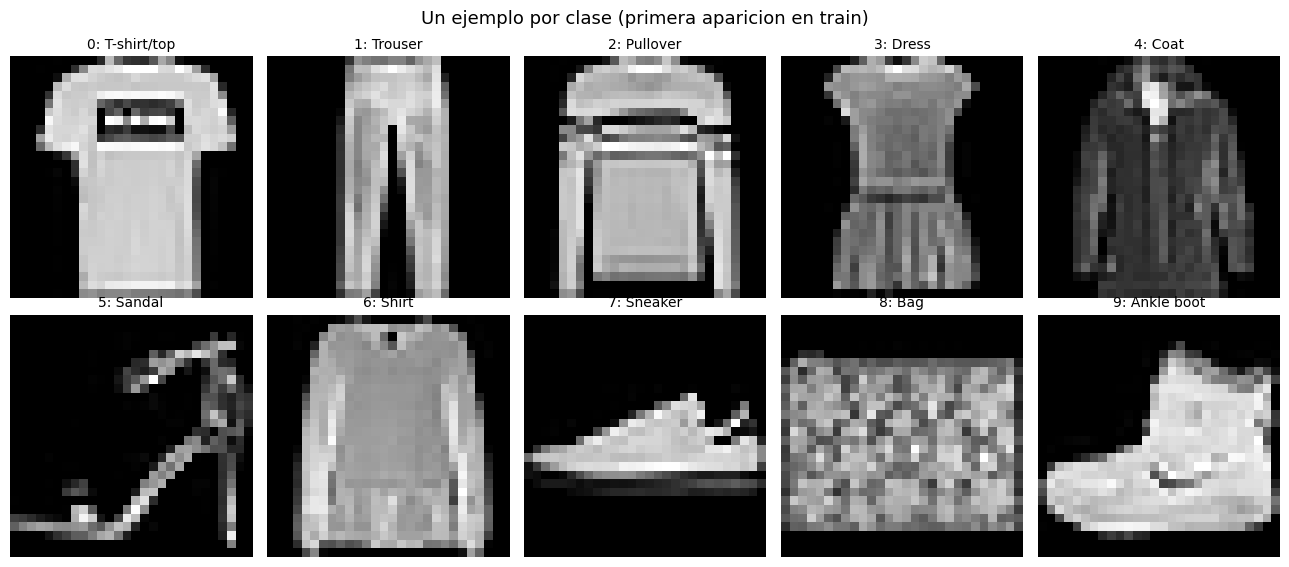

In [4]:
primeras = [np.where(y_train == c)[0][0] for c in range(10)] #Primera foto de cada clase que aparece en el dataset.
grilla_imagenes([X_train[i] for i in primeras],
                [f'{c}: {NOMBRES_CLASES[c]}' for c in range(10)],
                2, 5, 'Un ejemplo por clase (primera aparicion en train)', vmin=0, vmax=255)

 Conclusiones — Ejemplos por clase

A priori las clases parecieran verse centradas.

 3. Balance de clases
Analizamos si el dataset está balanceado. Esto es importante para evitar que métricas como el accuracy queden sesgadas por una clase que sea predominante.


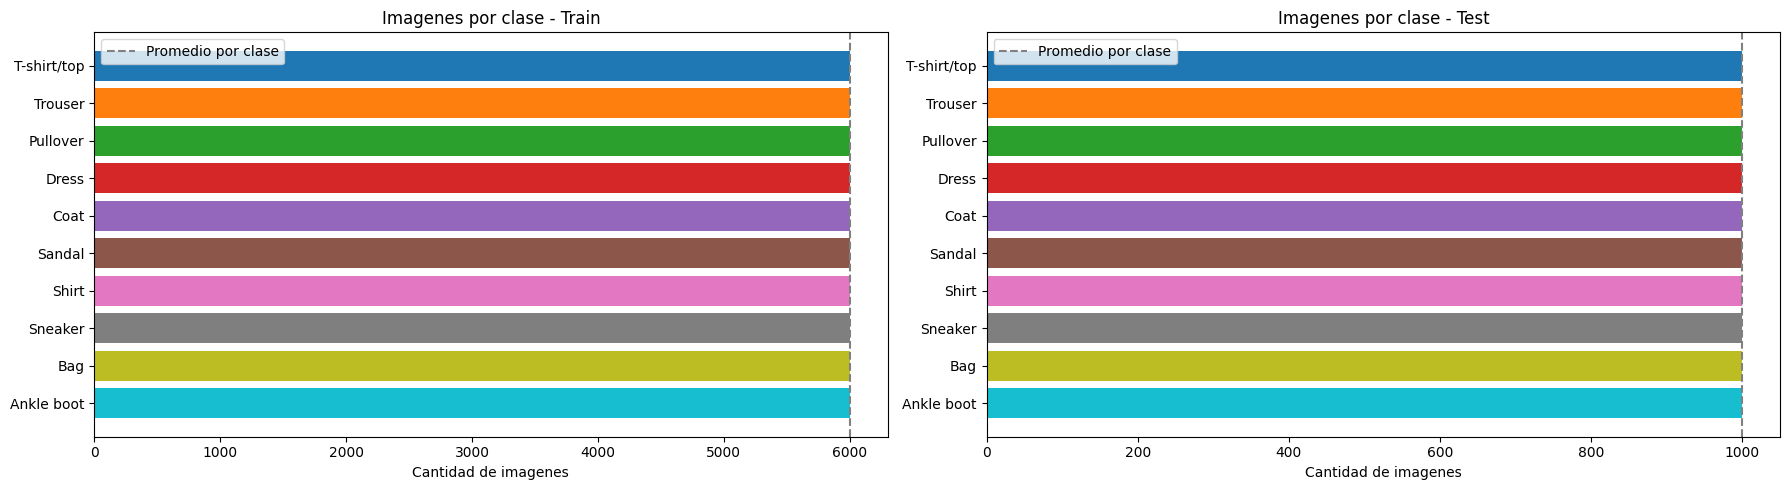

,Train,% Train,Test,% Test
Clase,,,,
T-shirt/top,6000,10.0,1000,10.0
Trouser,6000,10.0,1000,10.0
Pullover,6000,10.0,1000,10.0
Dress,6000,10.0,1000,10.0
Coat,6000,10.0,1000,10.0
Sandal,6000,10.0,1000,10.0
Shirt,6000,10.0,1000,10.0
Sneaker,6000,10.0,1000,10.0
Bag,6000,10.0,1000,10.0


Accuracy de un clasificador que adivina al azar: 10.00%


In [5]:
cuentas_train = pd.Series(y_train).value_counts().sort_index()
cuentas_test = pd.Series(y_test).value_counts().sort_index()
tabla_balance = pd.DataFrame({
    'Clase': NOMBRES_CLASES,
    'Train': cuentas_train.values,
    '% Train': cuentas_train.values / len(y_train) * 100,
    'Test': cuentas_test.values,
    '% Test': cuentas_test.values / len(y_test) * 100,
}).set_index('Clase')

fig, ejes = plt.subplots(1, 2, figsize=(18, 5), sharex=False)
for ax, cuentas, nombre in zip(ejes, [cuentas_train, cuentas_test], ['Train', 'Test']):
    ax.barh(NOMBRES_CLASES, cuentas.values, color=PALETA_CLASES)
    ax.axvline(cuentas.values.mean(), color='gray', linestyle='--', label='Promedio por clase')
    ax.set_title(f'Imagenes por clase - {nombre}')
    ax.set_xlabel('Cantidad de imagenes')
    ax.invert_yaxis()
    ax.legend()
plt.tight_layout()
plt.show()

mostrar_lado_a_lado([('Conteo y proporcion por clase', tabla_balance)], cmap='Blues', precision=1)
print(f'Accuracy de un clasificador que adivina al azar: {1 / 10:.2%}')

 Conclusiones — Balance de clases
Como podemos ver las clases estan completamente balanceadas, por lo que en este caso es  válido aplicar el accuraccy. La exactitud (accuracy) se vuelve engañosa principalmente cuando hay desbalance entre clases ya que si predice solo la clase mayoritaria el accuracy solo infla el puntaje sin realmente ser capaz de aprender. Al estar las clases completamente balanceadas la tasa de aciertos refleja de manera fiel el rendimiento general del modelo. Optuna puede usar accuracy como función objetivo a maximizar sin riesgo de caer en el sesgo de clase mayoritaria.



4. Distribución de intensidades de píxel
Se analiza la frecuencia de cada intensidad dentro del dataset de train, y los píxeles iguales a 0 en el dataset por clase. También, se analiza con box plots la intensidad media por imagen y por clase.

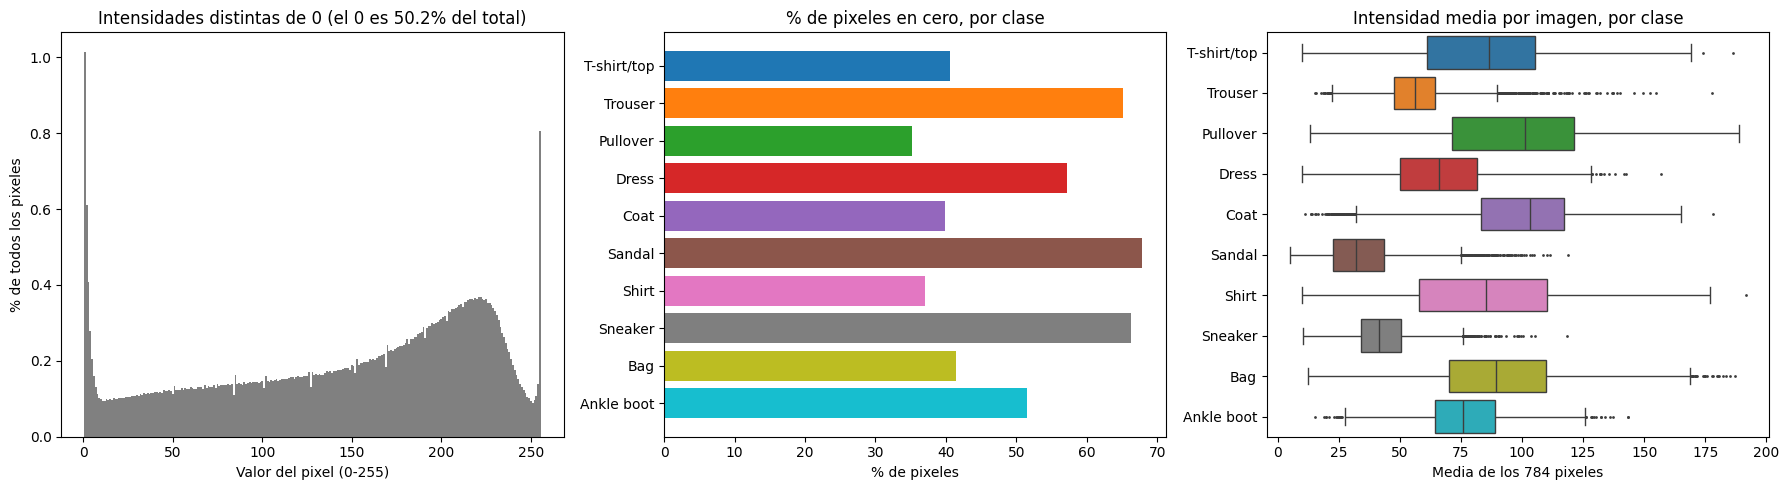

,Media,Desvio,Minimo,Maximo
Clase,,,,
T-shirt/top,83.0,28.9,9.8,186.3
Trouser,56.8,14.5,15.1,177.8
Pullover,96.1,32.7,13.2,188.7
Dress,66.0,21.4,9.8,156.9
Coat,98.3,26.4,11.1,178.1
Sandal,34.9,15.8,4.9,118.8
Shirt,84.6,33.1,10.0,191.8
Sneaker,42.8,12.8,10.4,118.3
Bag,90.2,28.8,12.2,187.2


In [6]:
conteo_valores = np.bincount(X_train.ravel(), minlength=256)
pct_ceros_clase = [(X_train[y_train == c] == 0).mean() * 100 for c in range(10)]
media_por_imagen = X_train.reshape(len(X_train), -1).mean(axis=1)

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

ejes[0].bar(np.arange(1, 256), conteo_valores[1:] / conteo_valores.sum() * 100, color='gray', width=1.0)
ejes[0].set_title(f'Intensidades distintas de 0 (el 0 es {conteo_valores[0] / conteo_valores.sum():.1%} del total)')
ejes[0].set_xlabel('Valor del pixel (0-255)')
ejes[0].set_ylabel('% de todos los pixeles')

ejes[1].barh(NOMBRES_CLASES, pct_ceros_clase, color=PALETA_CLASES)
ejes[1].set_title('% de pixeles en cero, por clase')
ejes[1].set_xlabel('% de pixeles')
ejes[1].invert_yaxis()

nombres_train = [NOMBRES_CLASES[c] for c in y_train]
sns.boxplot(x=media_por_imagen, y=nombres_train, hue=nombres_train, order=NOMBRES_CLASES,
            hue_order=NOMBRES_CLASES, palette=dict(zip(NOMBRES_CLASES, PALETA_CLASES)),
            orient='h', legend=False, ax=ejes[2], fliersize=1)
ejes[2].set_title('Intensidad media por imagen, por clase')
ejes[2].set_xlabel('Media de los 784 pixeles')
ejes[2].set_ylabel('')
plt.tight_layout()
plt.show()

resumen_int = pd.DataFrame({'Clase': [NOMBRES_CLASES[c] for c in y_train], 'media': media_por_imagen}) \
    .groupby('Clase')['media'].agg(['mean', 'std', 'min', 'max']).reindex(NOMBRES_CLASES)
resumen_int.columns = ['Media', 'Desvio', 'Minimo', 'Maximo']
mostrar_lado_a_lado([('Intensidad media por imagen (escala 0-255)', resumen_int)], cmap='Blues', precision=1)

A partir del análisis exploratorio, se observa que la proporción de datos correspondientes al fondo —definidos como aquellos píxeles con valor igual a cero— representa el 50,2 % del total. Esto indica que prácticamente la mitad de la información del conjunto de datos corresponde al fondo de las imágenes.

En términos prácticos, esta distribución implica que una fracción considerable de los píxeles periféricos permanece en cero de manera casi constante en todas las instancias. Al representar las imágenes en una matriz de 28 × 28 píxeles y proceder a su linealización en un vector de características, se generan múltiples variables con valores nulos continuos a lo largo de las observaciones, originadas por los márgenes periféricos. En consecuencia, dichas dimensiones presentan una varianza nula o prácticamente nula. Esta condición fundamenta la utilidad de aplicar técnicas de reducción de dimensionalidad, como el Análisis de Componentes Principales (PCA), o bien métodos directos como el filtrado por umbral de varianza (*Variance Thresholding*), permitiendo descartar variables no informativas resultantes del aplanamiento (*flattening*).

Asimismo, el análisis de densidad de píxeles activos (valores distintos de cero) evidencia patrones diferenciales según la morfología de cada clase. Ciertas prendas presentan una menor ocupación espacial —como ocurre con sandalias, zapatillas o pantalones— en contraste con prendas de mayor cobertura de superficie o densidad de intensidad, tales como pulóveres, bolsos, remeras o abrigos. Si bien la sola proporción de píxeles no nulos no constituye un criterio suficiente para clasificar de forma exhaustiva el conjunto de datos, sí proporciona un indicio heurístico inicial que permite discriminar preliminarmente entre grupos de clases con mayor y menor ocupación espacial.

Por último, en relación con el preprocesamiento mediante el escalado de características (división por 255):

* **Modelos basados en árboles (Random Forest):** La normalización no altera el rendimiento del clasificador. Los árboles de decisión generan particiones binarias dependientes únicamente del orden relativo de los valores; por lo tanto, cualquier transformación monótona creciente preserva la estructura de división sin impactar en las predicciones ni en la optimización.
* **Redes neuronales (*MLPClassifier*):** La normalización resulta determinante. Los perceptrones multicapa operan mediante sumas ponderadas y algoritmos de optimización basados en el descenso del gradiente. Mantener entradas en el rango original [0, 255], en lugar de acotarlas al intervalo [0, 1], puede provocar oscilaciones en los gradientes, saturación en las funciones de activación y convergencia hacia mínimos subóptimos. Escalar los valores al rango [0, 1] estabiliza la magnitud de los gradientes, acelera la convergencia y optimiza el proceso de aprendizaje del modelo.

5. Imagen media y desvío por píxel, por clase
Se analiza la imagen media de cada clase y el desvío estándar de cada píxel.

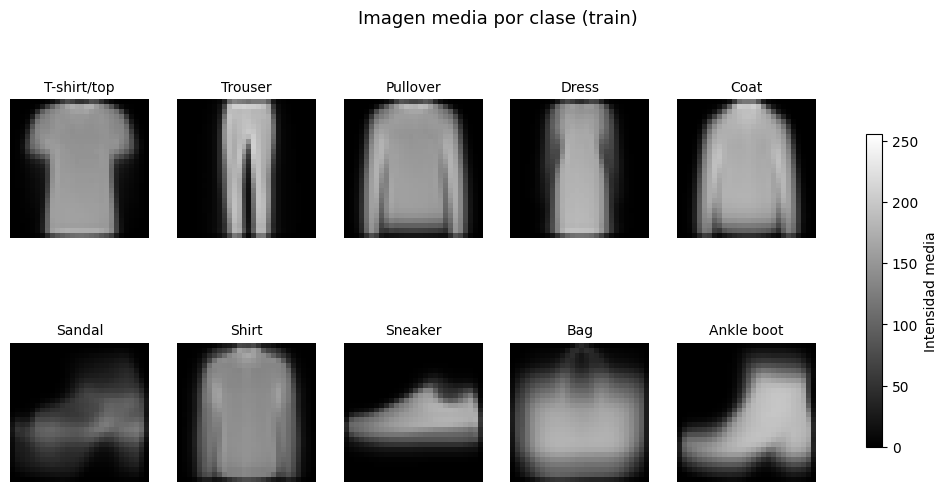

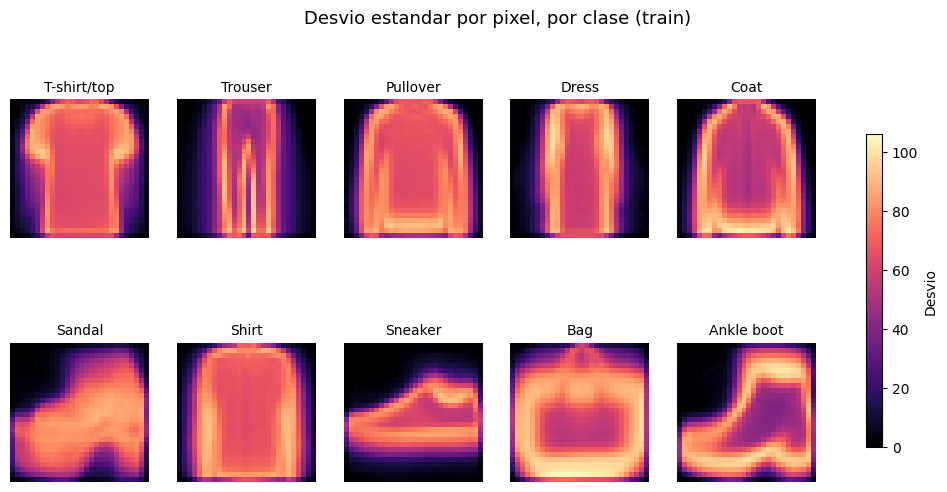

,Pixeles por debajo (de 784)
Umbral de desvio global (0-255),
0,0
5,20
20,73
50,167


In [7]:
medias = np.stack([X_train[y_train == c].mean(axis=0) for c in range(10)])
desvios = np.stack([X_train[y_train == c].std(axis=0) for c in range(10)])

grilla_imagenes(medias, NOMBRES_CLASES, 2, 5, 'Imagen media por clase (train)',
                cmap='gray', vmin=0, vmax=255, colorbar_label='Intensidad media')
grilla_imagenes(desvios, NOMBRES_CLASES, 2, 5, 'Desvio estandar por pixel, por clase (train)',
                cmap='magma', vmin=0, vmax=desvios.max(), colorbar_label='Desvio')

desvio_global = X_train.std(axis=0)
bajos = pd.DataFrame({
    'Umbral de desvio global (0-255)': [0, 5, 20, 50],
    'Pixeles por debajo (de 784)': [int((desvio_global <= u).sum()) for u in [0, 5, 20, 50]],
}).set_index('Umbral de desvio global (0-255)')
mostrar_lado_a_lado([('Pixeles casi constantes', bajos)], cmap='Blues', precision=0)

 Conclusiones — Imagen media y desvío

Hay unos 167 píxeles que tienen un bajo desvío (otro indicio de que quizás sea necesario aplicar reducción de dimensionalidad).

 6. PCA: dimensionalidad efectiva
Se divide por 255 (misma normalización que pide el TP) y PCA centra los datos. No se usa StandardScaler porque todos los píxeles comparten unidad y escala, y estandarizar inflaría el ruido de los bordes casi constantes. Se fittea solo con train.

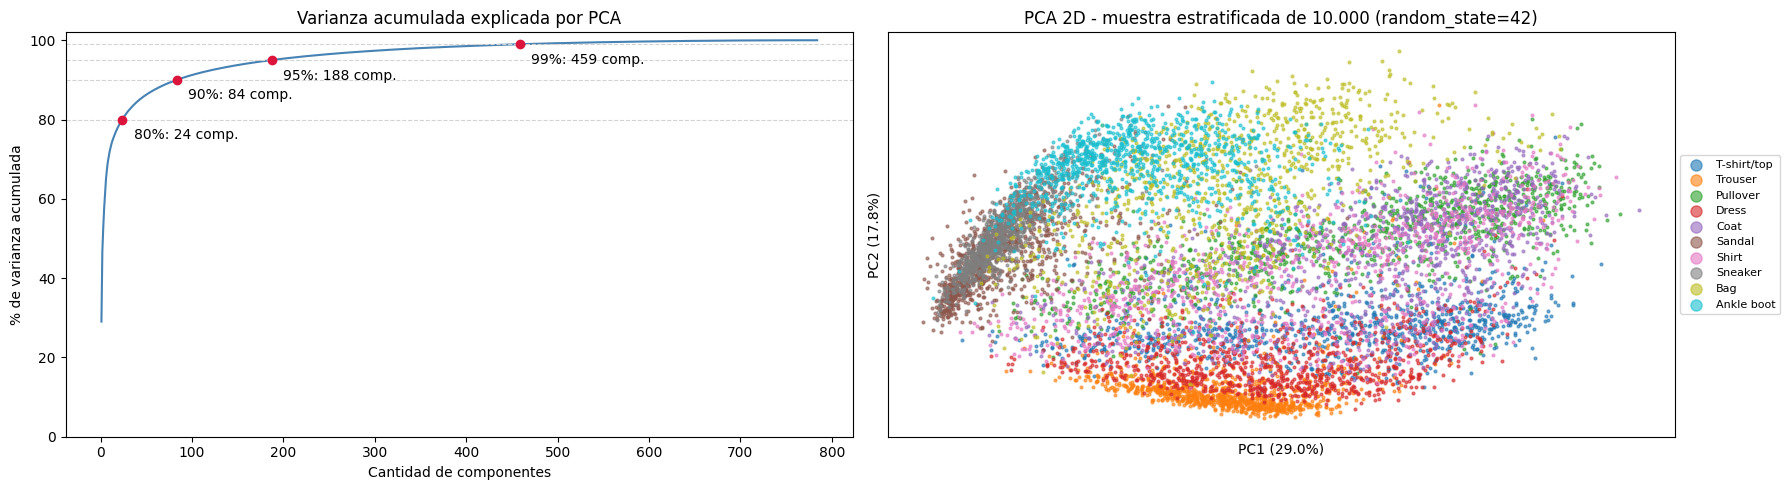

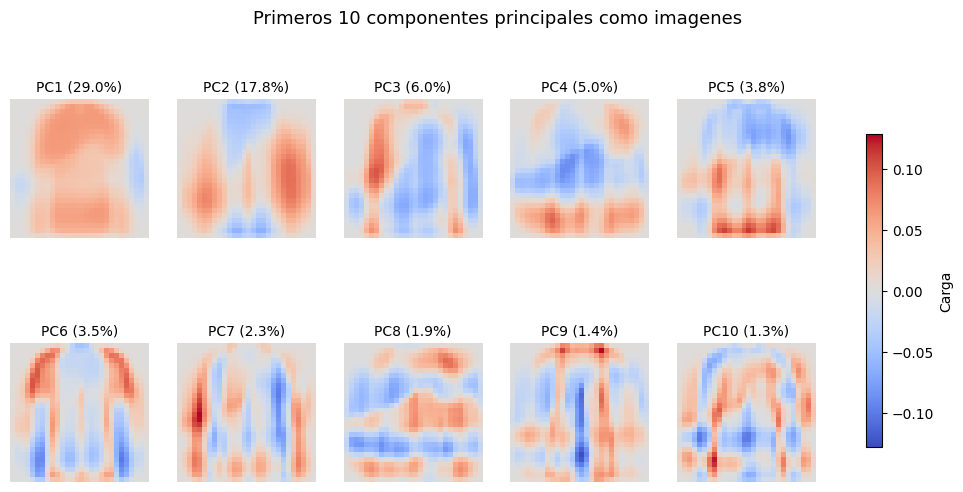

In [8]:
eda_X = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
eda_X_test = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

pca = PCA(random_state=SEMILLA).fit(eda_X)
var_acum = np.cumsum(pca.explained_variance_ratio_)
comp_para = {p: int(np.searchsorted(var_acum, p / 100) + 1) for p in [80, 90, 95, 99]}

Z_train = pca.transform(eda_X)[:, :50]   # solo los 50 primeros: es lo que usan t-SNE/UMAP despues
idx_dispersion = muestra_estratificada(y_train, 1000)   # 10.000 puntos: 60.000 saturaria el scatter

fig, ejes = plt.subplots(1, 2, figsize=(18, 5))
ejes[0].plot(np.arange(1, 785), var_acum * 100, color='steelblue')
for p, n in comp_para.items():
    ejes[0].axhline(p, color='lightgray', linestyle='--', linewidth=0.8)
    ejes[0].plot(n, p, 'o', color='crimson')
    ejes[0].annotate(f'{p}%: {n} comp.', (n, p), textcoords='offset points', xytext=(8, -14))
ejes[0].set_title('Varianza acumulada explicada por PCA')
ejes[0].set_xlabel('Cantidad de componentes')
ejes[0].set_ylabel('% de varianza acumulada')
ejes[0].set_ylim(0, 102)

dispersion_por_clase(Z_train[idx_dispersion], y_train[idx_dispersion], ejes[1],
                     'PCA 2D - muestra estratificada de 10.000 (random_state=42)')
ejes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ejes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ejes[1].legend(markerscale=4, fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

componentes = pca.components_[:10].reshape(10, 28, 28)
lim = np.abs(componentes).max()
grilla_imagenes(componentes, [f'PC{i + 1} ({pca.explained_variance_ratio_[i]:.1%})' for i in range(10)],
                2, 5, 'Primeros 10 componentes principales como imagenes',
                cmap='coolwarm', vmin=-lim, vmax=lim, colorbar_label='Carga')

 Conclusiones — PCA
A priori, el gráfico de las dos componentes principales muestra un gran solapamiento entre varias de las clases. Sin embargo, no confiar tanto en el gráfico, ya que reperesenta menos de la mitad de la varianza del dataset, por lo que la separabilidad de clases podrías ser más significativa de lo que parece.

Por otra parte, se puede apreciar que con solo 188 componentes (de un total de 784) se puede reperesentar el 95% de la varianza de los datos, mientras que con 84 llegamos al 90% de la varianza.

(Las cargas son los coeficientes de las componentes principales).

 7. Separabilidad entre pares de clases
Se observa qué clases son más fáciles de distinguir entre sí con las siguientes medidas:
- **Distancia entre imágenes medias normalizada**

Se calcula a partir de

Centro de cada clase. Es la imagen media de la clase, un vector de 784 valores. Calculad en sección 5.

Distancia entre medias: distancia euclídea entre los vectores de dos centros: `np.linalg.norm(centros[i] - centros[j])`. Mide cuán distinta es la "prenda típica" de una clase respecto de la otra.

Dispersión interna. Es cuánto se desparrama una clase alrededor de su propio centro: `np.sqrt(eda_X[y_train == c].var(axis=0).sum())`
Se calcula la varianza de cada uno de los 784 píxeles dentro de la clase, se suman y se saca la raíz. Es un único número por clase. Es grande si las imágenes de la clase se parecen poco entre sí y chico si son muy homogéneas.

Luego, se calcula: `distancia entre medias / dispersión interna típica del par`

Donde la dispersión del par es `sqrt((d_i² + d_j²) / 2)`, un promedio de las dos dispersiones.


- **Silueta por pares**: Este método sí mira los puntos uno por uno. Para cada imagen se calcula:

a = distancia promedio a las otras imágenes de su misma clase.

b = distancia promedio a las imágenes de la otra clase.

`s = (b − a) / max(a, b)`.


El cálculo se realizó en el espacio de 50 componentes de PCA (1.000 imágenes por par): al ser un método que revisa cada observación y la compara contra las otras, su costo computacional crece muy rápido para un N grande. Por eso, se optó con trabajar con 50 componentes y 500 imágenes de cada clase (es decir, 1000 por par) para disminuir el costo computacional.

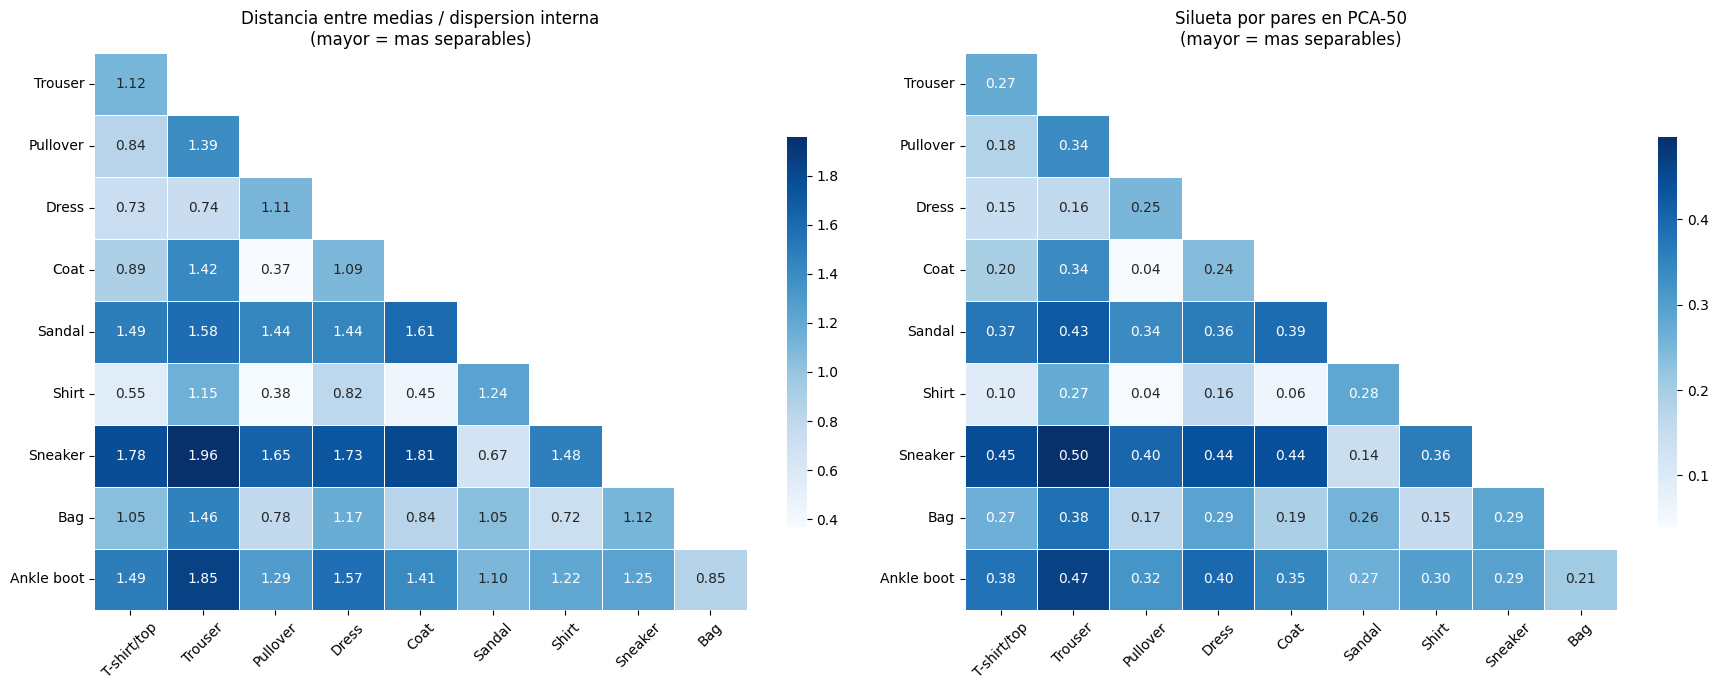

,Dist. normalizada,Silueta
Par,,
Coat vs Pullover,0.37,0.04
Shirt vs Pullover,0.38,0.04
Shirt vs Coat,0.45,0.06
Shirt vs T-shirt/top,0.55,0.10
Sneaker vs Sandal,0.67,0.14
,Dist. normalizada,Silueta
Par,,
Sneaker vs Trouser,1.96,0.50
Ankle boot vs Trouser,1.85,0.47


In [9]:
# Dispersion interna de cada clase: raiz de la varianza total (suma de varianzas de los 784 pixeles)
dispersion_interna = np.array([np.sqrt(eda_X[y_train == c].var(axis=0).sum()) for c in range(10)])
centros = np.stack([eda_X[y_train == c].mean(axis=0) for c in range(10)])

idx_sil = muestra_estratificada(y_train, 500)   # 500 por clase: silhouette es O(n^2) por par
Z_sil, y_sil = Z_train[idx_sil], y_train[idx_sil]

dist_norm = np.zeros((10, 10))
silueta = np.zeros((10, 10))
for i in range(10):
    for j in range(i):
        dist_norm[i, j] = np.linalg.norm(centros[i] - centros[j]) / np.sqrt((dispersion_interna[i] ** 2 + dispersion_interna[j] ** 2) / 2)
        m = np.isin(y_sil, [i, j])
        silueta[i, j] = silhouette_score(Z_sil[m], y_sil[m])

fig, ejes = plt.subplots(1, 2, figsize=(18, 7))
heatmap_triangular(dist_norm, 'Distancia entre medias / dispersion interna\n(mayor = mas separables)', ejes[0], 'Blues')
heatmap_triangular(silueta, 'Silueta por pares en PCA-50\n(mayor = mas separables)', ejes[1], 'Blues')
plt.tight_layout()
plt.show()

filas = []
for i in range(10):
    for j in range(i):
        filas.append({'Par': f'{NOMBRES_CLASES[i]} vs {NOMBRES_CLASES[j]}',
                      'Dist. normalizada': dist_norm[i, j], 'Silueta': silueta[i, j]})
ranking = pd.DataFrame(filas)
ranking['Rango medio'] = (ranking['Dist. normalizada'].rank() + ranking['Silueta'].rank()) / 2
ranking = ranking.sort_values('Rango medio').set_index('Par')
del ranking['Rango medio']

# El indice arma cada par como "clase de id mayor vs clase de id menor"
pares_guia = ranking.loc[['Ankle boot vs Sandal', 'Coat vs Pullover']]
mostrar_lado_a_lado([('5 pares mas DIFICILES', ranking.head(5)),
                     ('5 pares mas FACILES', ranking.tail(5).iloc[::-1]),
                     ('Ejemplos de la consigna', pares_guia)], cmap='Blues', precision=2)

 Conclusiones — Separabilidad entre pares

Se observa que las prendas más difíciles de separar corresponden a aquellas que se destinan a cubrir una misma parte del cuerpo (al usarse sobre la misma parte del cuerpo, se espera que tengan una morfología similar y que sean más difíciles de diferenciar, sobre todo para una resolución tan baja como 784 píxeles).

Por el contrario, pares como sneakers vs pantalón sí son más fáciles de separar ya que uno tiene que cubrir los pies, mientras que el otro debe cubrir las piernas. La morfologías de dichas prendas tenderá a ser bastante distinta entre ambas y ello facilita la separabilidad.

 8. Estructura no lineal: PCA vs. t-SNE vs. UMAP
t-SNE y UMAP se aplican sobre los 50 primeros componentes (como reducción de ruido previa y para disminuir el costo computacional) y sobre una muestra estratificada de 5.000 imágenes, porque t-SNE es costoso.

Recordemos que en t-SNE las distancias *globales*; solo se lee vecindad local. UMAP conserva algo más de estructura global, pero tampoco es una distancia literal. Los tres paneles usan las mismas 5.000 imágenes.

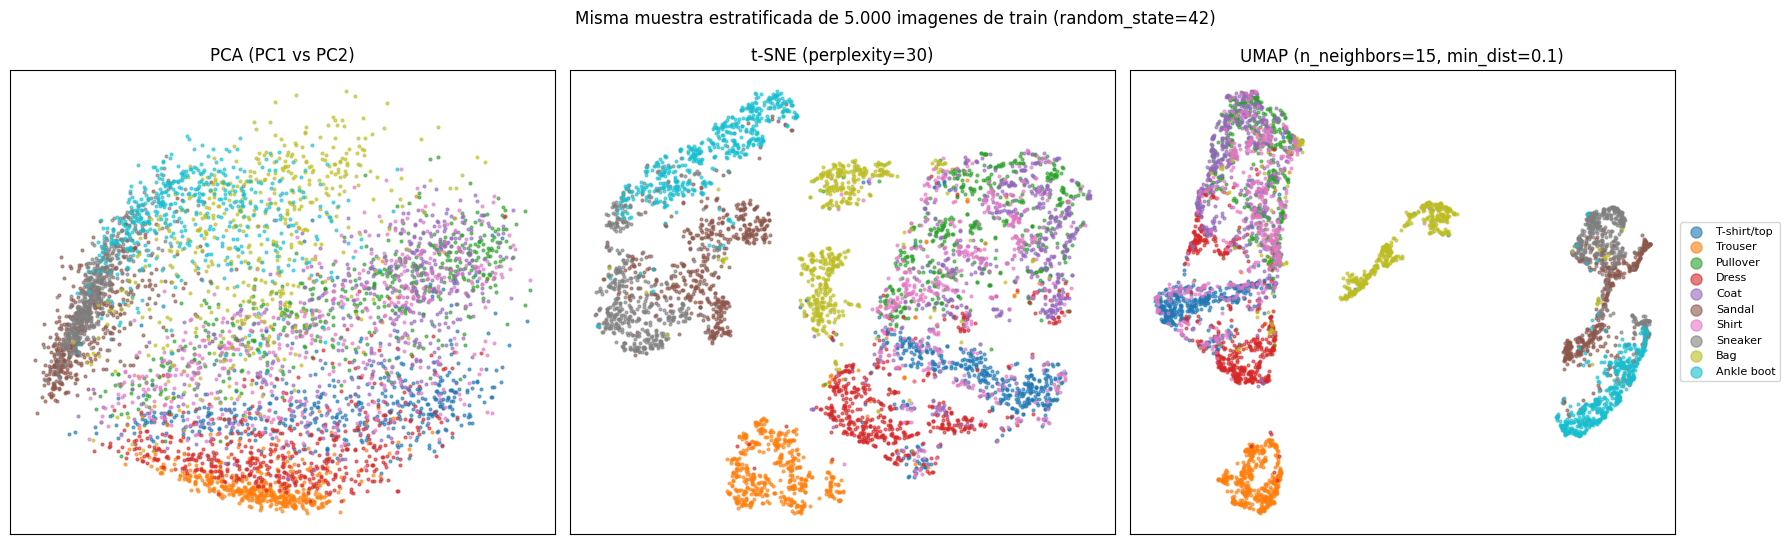

In [10]:
idx_no_lineal = muestra_estratificada(y_train, 500)   # 5.000 imagenes (500 por clase)
Z_entrada = Z_train[idx_no_lineal]
y_m = y_train[idx_no_lineal]

#Perplexity define cuántos vecinos "cuenta" cada punto como cercanos al armar el mapa.
Z_tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEMILLA).fit_transform(Z_entrada)
#min_dist no cambia los puntos, sino la distancia mínima que debe haber entre ellos para plotearse en el gráfico.
Z_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEMILLA, n_jobs=1).fit_transform(Z_entrada)

fig, ejes = plt.subplots(1, 3, figsize=(18, 5.5))
dispersion_por_clase(Z_entrada[:, :2], y_m, ejes[0], 'PCA (PC1 vs PC2)')
dispersion_por_clase(Z_tsne, y_m, ejes[1], 't-SNE (perplexity=30)')
dispersion_por_clase(Z_umap, y_m, ejes[2], 'UMAP (n_neighbors=15, min_dist=0.1)')
ejes[2].legend(markerscale=4, fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle('Misma muestra estratificada de 5.000 imagenes de train (random_state=42)')
plt.tight_layout()
plt.show()

Conclusiones — PCA vs. t-SNE vs. UMAP

Las clases de prendas destinadas a una misma parte del cuerpo siguen solapándose incluso bajo métodos no lineales. No obstante, t-SNE y UMAP logran separar mejor las clases que PCA (recordemos que las distancias entre clase sno son interpretables con estas técnicas).

t-SNE pareciera mostrar que existen dos subgrupos dentro de la clase `bag`.

9. Consistencia entre train y test
Corroboramos que los dos conjuntos sean parecidos. Si no lo son, un accuracy baja podría no ser causa de un mal modelo o mala selección de hiperparámetros.

Se compara la intensidad media por imagen y por clase (tabla con el estadístico de KS, que mide el tamaño de la diferencia; el p-valor no se usa porque con n = 60.000 vs. 10.000 rechaza diferencias irrelevantes) y las proyecciones PC1/PC2 de ambos conjuntos con el PCA ajustado solo en train.

PD: el estadístico KS mide cuánto se parecen dos distribuciones:

Para cada muestra se arma su función de distribución acumulada empírica (ECDF). Es una curva que, para cada valor x, dice qué fracción de la muestra es menor o igual a x. Va de 0 a 1.
Se dibujan las dos curvas juntas.
El estadístico KS = la máxima distancia vertical entre ambas curvas.
Va de 0 a 1:

0: las dos muestras tienen exactamente la misma distribución.
1: las distribuciones no se solapan para nada.
Ejemplo con números: si en x = 80 la muestra de train tiene el 40% de sus valores por debajo y la de test el 43%, la distancia en ese punto es 0,03. El KS es el mayor de esos 0,03 a lo largo de todo x. Si el máximo es 0,03, las distribuciones difieren como mucho en 3 puntos porcentuales.

En el código se hace con `stats.ks_2samp(a, b).statistic`.

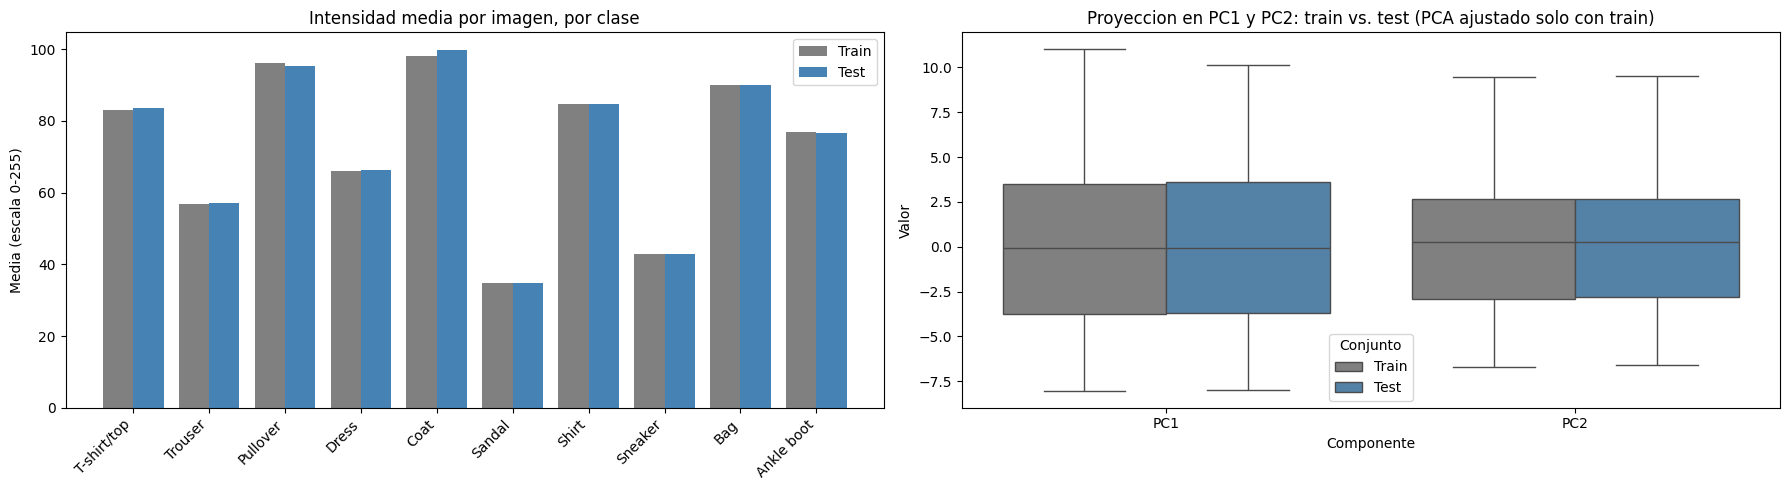

,Media train,Media test,Diferencia%,KS (estadistico)
Clase,,,,
T-shirt/top,83.030,83.624,0.710,0.036
Trouser,56.841,56.981,0.247,0.023
Pullover,96.059,95.353,-0.741,0.030
Dress,66.019,66.395,0.566,0.024
Coat,98.258,99.745,1.491,0.037
Sandal,34.868,34.757,-0.317,0.015
Shirt,84.605,84.858,0.298,0.020
Sneaker,42.762,43.020,0.599,0.022
Bag,90.157,90.139,-0.020,0.029


In [11]:
media_test = X_test.reshape(len(X_test), -1).mean(axis=1)
filas = []
for c in range(10):
    a, b = media_por_imagen[y_train == c], media_test[y_test == c]
    filas.append({'Clase': NOMBRES_CLASES[c], 'Media train': a.mean(), 'Media test': b.mean(),
                  'Diferencia%': 100*(b.mean() - a.mean())/b.mean(), 'KS (estadistico)': stats.ks_2samp(a, b).statistic})
tabla_tt = pd.DataFrame(filas).set_index('Clase')

Z_test = pca.transform(eda_X_test)[:, :2]
pcs = pd.concat([
    pd.DataFrame({'Componente': 'PC1', 'Conjunto': 'Train', 'Valor': Z_train[:, 0]}),
    pd.DataFrame({'Componente': 'PC2', 'Conjunto': 'Train', 'Valor': Z_train[:, 1]}),
    pd.DataFrame({'Componente': 'PC1', 'Conjunto': 'Test', 'Valor': Z_test[:, 0]}),
    pd.DataFrame({'Componente': 'PC2', 'Conjunto': 'Test', 'Valor': Z_test[:, 1]}),
])

fig, ejes = plt.subplots(1, 2, figsize=(18, 5))
ancho = 0.4
x = np.arange(10)
ejes[0].bar(x - ancho / 2, tabla_tt['Media train'], ancho, label='Train', color='gray')
ejes[0].bar(x + ancho / 2, tabla_tt['Media test'], ancho, label='Test', color='steelblue')
ejes[0].set_xticks(x)
ejes[0].set_xticklabels(NOMBRES_CLASES, rotation=45, ha='right')
ejes[0].set_title('Intensidad media por imagen, por clase')
ejes[0].set_ylabel('Media (escala 0-255)')
ejes[0].legend()

sns.boxplot(data=pcs, x='Componente', y='Valor', hue='Conjunto', palette={'Train': 'gray', 'Test': 'steelblue'},
            fliersize=1, ax=ejes[1])
#La proyección es el producto punto entre la PC y el vector normalizado y centrado de las imágenes).
ejes[1].set_title('Proyeccion en PC1 y PC2: train vs. test (PCA ajustado solo con train)')
plt.tight_layout()
plt.show()

mostrar_lado_a_lado([('Train vs. test por clase', tabla_tt)], cmap='Blues', precision=3)

 Conclusiones — Consistencia train/test

Las distribuciones entre train y test son bastante similares entre sí. Por lo tanto, podemos usar accuracy y confiar en que su resultado dependerá de la performance del modelo en sí y no de otros factores.

 10. Datos para los Ejercicios 2 y 3
Consolidamos en un solo lugar las cifras que ya se calcularon (nada se entrena acá). El costo de Optuna se expresa en cantidad de ajustes de árbol, no en tiempo, porque el tiempo depende de la naturaleza y especificaciones de la máquina (Colab/local, etc.) y solo se puede medir entrenando.

In [12]:
N_TRIALS_MIN = 50            # minimo que pide la consigna
FOLDS_ASUMIDOS = 5           # cross_val_score usa 5 folds por defecto en clasificacion
arboles_promedio = (50 + 200) / 2   # punto medio del rango de n_estimators de la consigna
arboles_totales = N_TRIALS_MIN * FOLDS_ASUMIDOS * arboles_promedio
n_fit_cv = int(len(eda_X) * (FOLDS_ASUMIDOS - 1) / FOLDS_ASUMIDOS)

insumos = pd.DataFrame({
    'Dato medido': [
        f'{len(eda_X):,} imagenes de train x 784 pixeles; 10 clases, de {cuentas_train.min():,} a {cuentas_train.max():,} imagenes cada una',
        f'{comp_para[95]} componentes explican 95% de la varianza; {comp_para[99]} explican 99%',
        f'{int((desvio_global <= 5).sum())} pixeles con desvio menor o igual a 5 (de 255); {int((plano_train.std(axis=0) == 0).sum())} con varianza cero',
        f'{conteo_valores[0] / conteo_valores.sum():.1%} de los pixeles vale 0; el resto va de 1 a 255',
        f'{N_TRIALS_MIN} trials x {FOLDS_ASUMIDOS} folds x ~{arboles_promedio:.0f} arboles = ~{arboles_totales:,.0f} arboles, cada uno sobre ~{n_fit_cv:,} imagenes',
        f'Clase con menos imagenes: {cuentas_train.min():,}; azar = {1 / 10:.0%}',
        f'Diferencia maxima train-test en intensidad media por clase: {tabla_tt["Diferencia%"].abs().max():.2f}%',
    ],
    'Ejercicio que informa': [
        'Ej. 2 (costo por trial); Ej. 3 (tiempo por epoca)',
        'Ej. 1 y 2 (max_depth, cantidad efectiva de features)',
        'Ej. 1 y 2 (features irrelevantes para RF)',
        'Ej. 3 (escala de entrada del MLP)',
        'Ej. 2 (presupuesto de Optuna)',
        'Ej. 2 y 3 (accuracy como objetivo)',
        'Ej. 1, 2 y 3 (validez de comparar train vs. test)',
    ],
})
mostrar_tabla_texto(insumos)

Dato medido,Ejercicio que informa
"60,000 imagenes de train x 784 pixeles; 10 clases, de 6,000 a 6,000 imagenes cada una",Ej. 2 (costo por trial); Ej. 3 (tiempo por epoca)
188 componentes explican 95% de la varianza; 459 explican 99%,"Ej. 1 y 2 (max_depth, cantidad efectiva de features)"
20 pixeles con desvio menor o igual a 5 (de 255); 0 con varianza cero,Ej. 1 y 2 (features irrelevantes para RF)
50.2% de los pixeles vale 0; el resto va de 1 a 255,Ej. 3 (escala de entrada del MLP)
"50 trials x 5 folds x ~125 arboles = ~31,250 arboles, cada uno sobre ~48,000 imagenes",Ej. 2 (presupuesto de Optuna)
"Clase con menos imagenes: 6,000; azar = 10%",Ej. 2 y 3 (accuracy como objetivo)
Diferencia maxima train-test en intensidad media por clase: 1.49%,"Ej. 1, 2 y 3 (validez de comparar train vs. test)"


In [13]:
import numpy as np

# Simulamos un lote de 1000 imágenes de 28x28 con valores de 0 a 255
# Forma original: (1000, 28, 28)
X = np.random.randint(0, 256, size=(1000, 28, 28))
print(f"Forma original: {X.shape}")
# Salida: Forma original: (1000, 28, 28)

#Aplanar las imágenes a 784 características
# X.shape[0] mantiene la cantidad de imágenes (1000)
# El '-1' le dice a NumPy que calcule automáticamente la otra dimensión (28 * 28 = 784)
X_aplanado = X.reshape(X.shape[0], -1)
print(f"Forma aplanada: {X_aplanado.shape}")
# Salida: Forma aplanada: (1000, 784)

#  Normalizar los valores dividiendo entre 255.0
X = X_aplanado / 255.0

print(f"Rango de valores: Mínimo {X.min()}, Máximo {X.max()}")
# Salida: Rango de valores: Mínimo 0.0, Máximo 1.0

Forma original: (1000, 28, 28)
Forma aplanada: (1000, 784)
Rango de valores: Mínimo 0.0, Máximo 1.0


In [14]:
# Normalizar y aplanar las imágenes de entrenamiento
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0

# Normalizar y aplanar las imágenes de test
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

#Ejercicio 1.1

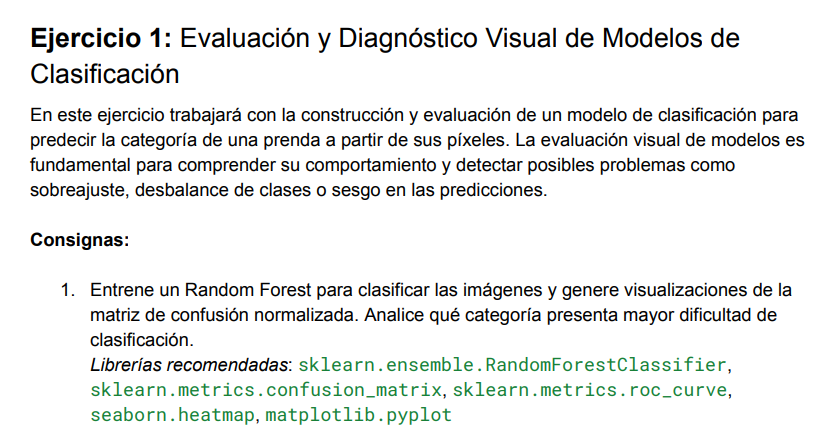

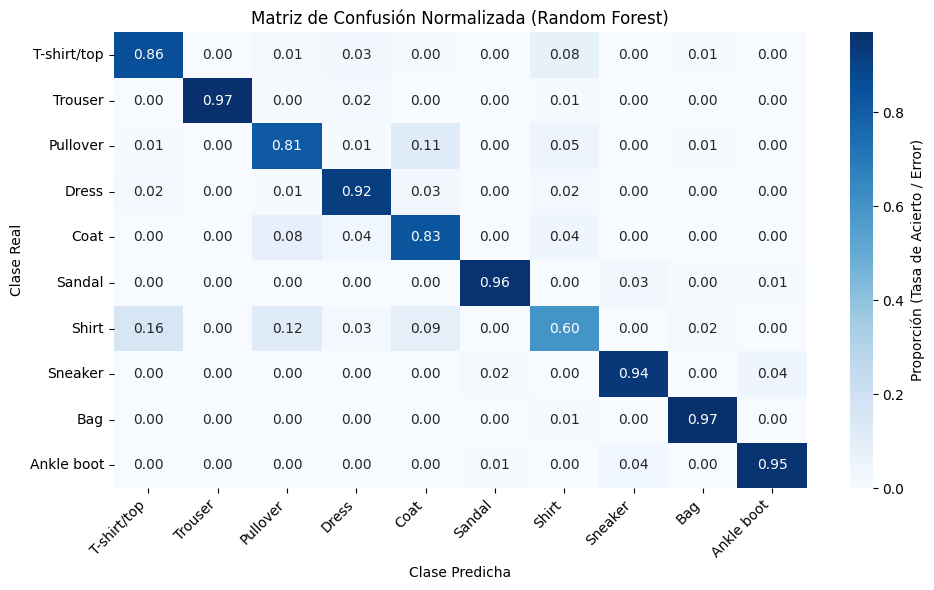


Métricas de clasificación:


,precision,recall,f1-score,support
T-shirt/top,0.820,0.860,0.839,6000.000000
Trouser,0.993,0.965,0.979,6000.000000
Pullover,0.782,0.812,0.796,6000.000000
Dress,0.876,0.919,0.897,6000.000000
Coat,0.778,0.833,0.805,6000.000000
Sandal,0.966,0.955,0.961,6000.000000
Shirt,0.737,0.595,0.659,6000.000000
Sneaker,0.933,0.937,0.935,6000.000000
Bag,0.956,0.970,0.963,6000.000000
Ankle boot,0.946,0.952,0.949,6000.000000


In [17]:
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

y = y_train
X=X_train

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# cross_val_predict garantiza evaluar sobre datos no vistos en cada fold
y_pred = cross_val_predict(rf_clf, X, y, cv=3)

# Matriz de confusión normalizada por fila
cm = confusion_matrix(y, y_pred)
cm_norm = confusion_matrix(y, y_pred, normalize="true")

# Visualización con Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=NOMBRES_CLASES,
    yticklabels=NOMBRES_CLASES,
    cbar_kws={"label": "Proporción (Tasa de Acierto / Error)"},
    ax=ax,
)
plt.title("Matriz de Confusión Normalizada (Random Forest)")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Reporte de métricas por clase
reporte = classification_report(
    y,
    y_pred,
    target_names=NOMBRES_CLASES,
    output_dict=True
)

metricas = pd.DataFrame(reporte).T
metricas = metricas.round(3)

print("\nMétricas de clasificación:")
display(
    metricas.style
    .background_gradient(cmap="Blues", subset=["precision", "recall", "f1-score"])
    .format("{:.3f}", subset=["precision", "recall", "f1-score"])
)

In [18]:
# Ranking de las 10 confusiones más frecuentes
errores = []

for i in range(len(NOMBRES_CLASES)):
    for j in range(len(NOMBRES_CLASES)):
        if i != j:
            errores.append({
                "Clase real": NOMBRES_CLASES[i],
                "Clase predicha": NOMBRES_CLASES[j],
                "Tasa de error": cm_norm[i, j]
            })

ranking_errores = pd.DataFrame(errores)

ranking_errores = (
    ranking_errores
    .sort_values("Tasa de error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

ranking_errores.index = ranking_errores.index + 1

print("\nTop 10 de confusiones más frecuentes:")

display(
    ranking_errores.style
    .background_gradient(
        cmap="Reds",
        subset=["Tasa de error"]
    )
    .format({"Tasa de error": "{:.3f}"})
)


Top 10 de confusiones más frecuentes:


,Clase real,Clase predicha,Tasa de error
1,Shirt,T-shirt/top,0.158
2,Shirt,Pullover,0.117
3,Pullover,Coat,0.113
4,Shirt,Coat,0.088
5,Coat,Pullover,0.081
6,T-shirt/top,Shirt,0.078
7,Pullover,Shirt,0.052
8,Sneaker,Ankle boot,0.044
9,Coat,Shirt,0.043
10,Coat,Dress,0.035


Podemos observar que mediante un Random Forest se logra obtener un buen desempeño en la clasificación de las imágenes, presentando tasas de error relativamente bajas. La mayor dificultad se encuentra en la clasificación de remeras como camisas, donde se observa una tasa de error de 0,16. Además, podemos observar que existen varias categorías que presentan tasas de error de cero, lo cual indica que no se observaron confusiones entre esas categorías en esa dirección. En general, los resultados muestran un buen desempeño del clasificador para distinguir las diferentes prendas.

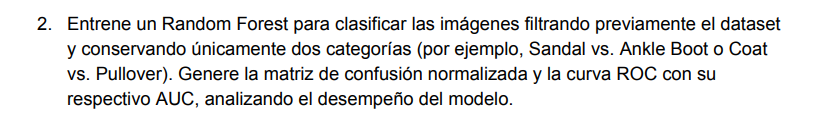

##1.2

Para el segundo ejercicio, vamos a analizar dos casos particulares. Por un lado, vamos a tomar el par que presentó mayor dificultad en el ejercicio anterior, correspondiente a remera y camisa, para analizar su matriz de confusión y su curva ROC con su respectivo AUC. Por otro lado, vamos a tomar un par que presentó una tasa de error de cero, correspondiente a pantalones y camperas.

Elegimos estos dos pares para comparar el desempeño del modelo en un caso que podemos considerar difícil y otro que podemos considerar fácil.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split


def evaluar_par(clase_1, clase_2):
    # Filtrar únicamente las dos categorías seleccionadas
    idx = np.isin(y_train, [clase_1, clase_2])

    X_par = X_train[idx]
    y_par = y_train[idx]

    # Convertir las imágenes a vectores y normalizar
    X_par = X_par.reshape(len(X_par), -1) / 255.0

    # Convertir las etiquetas a 0 y 1
    y_bin = (y_par == clase_2).astype(int)

    # Separar en entrenamiento y prueba
    X_train_par, X_test_par, y_train_par, y_test_par = train_test_split(
        X_par,
        y_bin,
        test_size=0.2,
        random_state=42,
        stratify=y_bin
    )

    # Entrenar Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_par, y_train_par)

    # Predicciones
    y_pred = rf.predict(X_test_par)

    # Probabilidad de pertenecer a la clase positiva
    y_prob = rf.predict_proba(X_test_par)[:, 1]

    cm_norm = confusion_matrix(
        y_test_par,
        y_pred,
        normalize="true"
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=[NOMBRES_CLASES[clase_1], NOMBRES_CLASES[clase_2]],
        yticklabels=[NOMBRES_CLASES[clase_1], NOMBRES_CLASES[clase_2]],
        cbar_kws={"label": "Proporción"}
    )

    plt.title(
        f"Matriz de Confusión Normalizada\n"
        f"{NOMBRES_CLASES[clase_1]} vs {NOMBRES_CLASES[clase_2]}"
    )
    plt.xlabel("Clase Predicha")
    plt.ylabel("Clase Real")
    plt.tight_layout()
    plt.show()
    # Matriz de confusión sin normalizar
    cm = confusion_matrix(y_test_par, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[NOMBRES_CLASES[clase_1], NOMBRES_CLASES[clase_2]],
    yticklabels=[NOMBRES_CLASES[clase_1], NOMBRES_CLASES[clase_2]],
    cbar_kws={"label": "Cantidad de imágenes"}
    )

    plt.title(
    f"Matriz de Confusión\n"
    f"{NOMBRES_CLASES[clase_1]} vs {NOMBRES_CLASES[clase_2]}"
    )
    plt.xlabel("Clase Predicha")
    plt.ylabel("Clase Real")
    plt.tight_layout()
    plt.show()

  #hacemos la curva roc
    fpr, tpr, thresholds = roc_curve(y_test_par, y_prob)
    auc = roc_auc_score(y_test_par, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(
        fpr,
        tpr,
        label=f"Random Forest (AUC = {auc:.3f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Clasificador aleatorio"
    )

    plt.title(
        f"Curva ROC\n"
        f"{NOMBRES_CLASES[clase_1]} vs {NOMBRES_CLASES[clase_2]}"
    )
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        f"AUC para {NOMBRES_CLASES[clase_1]} vs "
        f"{NOMBRES_CLASES[clase_2]}: {auc:.3f}"
    )


    return auc

Caso "dificíl" Camisa vs remera

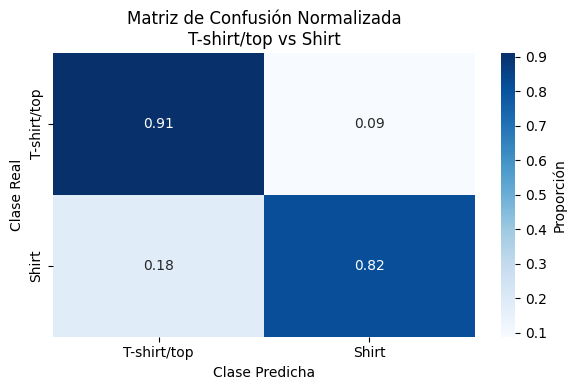

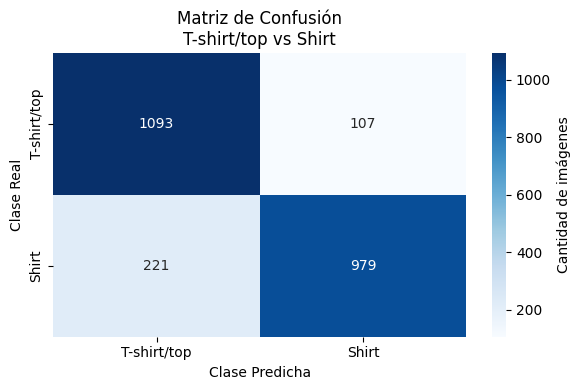

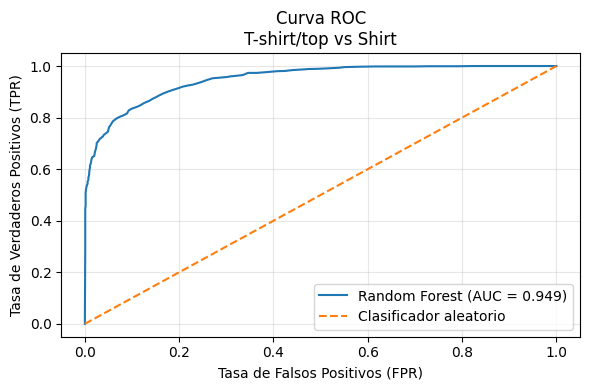

AUC para T-shirt/top vs Shirt: 0.949


In [20]:
auc_tshirt_shirt = evaluar_par(0, 6)

Caso "fácil" pantalón vs campera

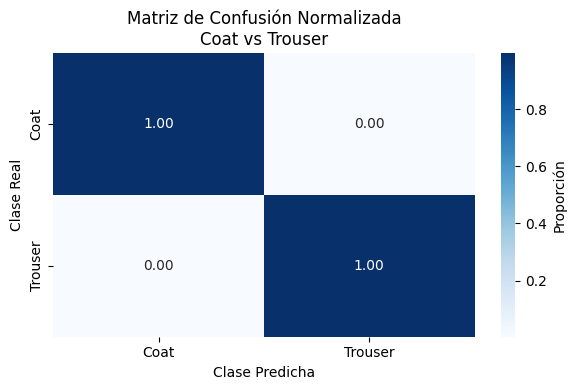

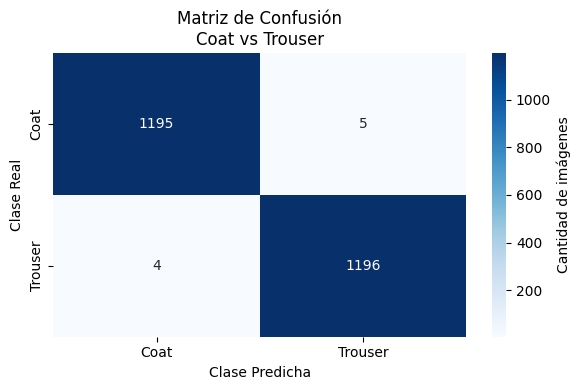

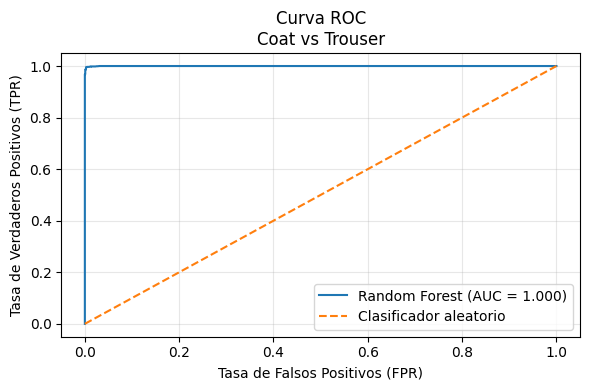

AUC para Coat vs Trouser: 1.000


In [21]:
auc_coat_trouser = evaluar_par(4, 1)

Como conclusión, podemos observar que, efectivamente, como habíamos previsto anteriormente, en el caso de campera y pantalón se obtiene un AUC de 1, que corresponde al valor máximo posible y representa una separación perfecta entre ambas clases en el conjunto de prueba. En cambio, para el par remera y camisa se obtiene un AUC de 0,946. Este valor también representa un muy buen desempeño del clasificador, aunque no es perfecto y todavía existen algunas dificultades para distinguir entre ambas categorías. Esto resulta coherente con la mayor similitud visual entre las prendas y con la dificultad que ya habíamos observado en la clasificación de las diez categorías.

#Ejercicio 2

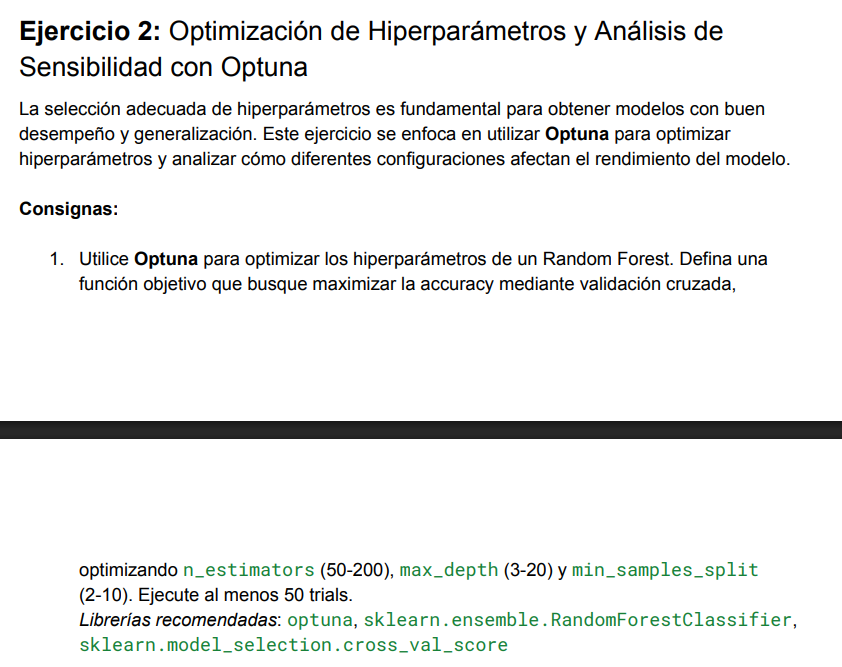

In [22]:
# !pip install optuna   #
import optuna
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split

SEMILLA = 42
N_SUBMUESTRA = 15000

#Aplanar
X_tr = X_train.reshape(len(X_train), -1).astype(np.float32)

# Submuestra estratificada solo para la BUSQUEDA (misma cantidad por clase)
X_busq, _, y_busq, _ = train_test_split(
    X_tr, y_train, train_size=N_SUBMUESTRA, stratify=y_train, random_state=SEMILLA)

# Mismos 5 folds para todos los trials
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)


def objetivo(trial):
    # 1) Optuna propone una combinacion dentro de los rangos indicados
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    # 2) Se arma el modelo con esa combinación
    modelo = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=SEMILLA,
        n_jobs=-1,
    )

    # 3) Validación cruzada fold por fold (en vez de cross_val_score) para poder
    #    informar el avance y cortar el trial si va mal
    puntajes = []
    for i, (idx_entreno, idx_valid) in enumerate(cv.split(X_busq, y_busq)):
        m = clone(modelo).fit(X_busq[idx_entreno], y_busq[idx_entreno])
        puntajes.append(m.score(X_busq[idx_valid], y_busq[idx_valid])) #accuracy del fold

        trial.report(np.mean(puntajes), step=i)# accuracy media hasta el momento
        # En el ultimo fold el trial ya terminó: podarlo descartaría un resultado completo
        if i < cv.get_n_splits() - 1 and trial.should_prune(): # peor que la mediana de los trials previos
            raise optuna.TrialPruned()

    return np.mean(puntajes)


optuna.logging.set_verbosity(optuna.logging.WARNING)

estudio = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEMILLA),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,    # los primeros 10 trials nunca se podan (no hay mediana confiable)
        n_warmup_steps=1,       # no se poda con 1 o 2 folds: con tan pocos el promedio es ruidoso
    ),
)
estudio.optimize(objetivo, n_trials=50, show_progress_bar=True)

# Resumen: cuantos trials terminaron y cuantos se podaron
estados = estudio.trials_dataframe()['state'].value_counts()
print(estados.to_string())
print(f'\nMejor accuracy (CV, 5 folds, submuestra de {N_SUBMUESTRA:,}): {estudio.best_value:.4f}')
print('Mejores hiperparametros:', estudio.best_params)

# Los 10 mejores trials COMPLETOS (los podados no tienen accuracy final)
trials = estudio.trials_dataframe()
trials = trials[trials['state'] == 'COMPLETE'][
    ['number', 'value', 'params_n_estimators', 'params_max_depth', 'params_min_samples_split']]
trials.columns = ['Trial', 'Accuracy CV', 'n_estimators', 'max_depth', 'min_samples_split']
trials.sort_values('Accuracy CV', ascending=False).head(10).round(4)


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-10-08 20:06:19,921] Trial 0 failed with parameters: {'n_estimators': 106, 'max_depth': 20, 'min_samples_split': 8} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_19607/1231387079.py", line 41, in objetivo
    m = clone(modelo).fit(X_busq[idx_entreno], y_busq[idx_entreno])
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py", line 487, in fit
    trees = Parallel(
    ...<2 lines>...
        prefer="threads",
    )(
        delayed(_parallel_build_trees)(
    ...<12 lines>...
        for i, t in enumerate(trees)
    )
  File "/usr/local/lib/python3.13/dist-packages/sklearn/utils/parallel.py", line 77, in __call__
    return s

KeyboardInterrupt: 

In [ ]:
modelo_final = RandomForestClassifier(**estudio.best_params, random_state=SEMILLA, n_jobs=-1)
modelo_final.fit(X_tr, y_train) #training con las 60.000 imágenes
X_te = X_test.reshape(len(X_test), -1).astype(np.float32)
print(f'Accuracy en test: {modelo_final.score(X_te, y_test):.4f}')


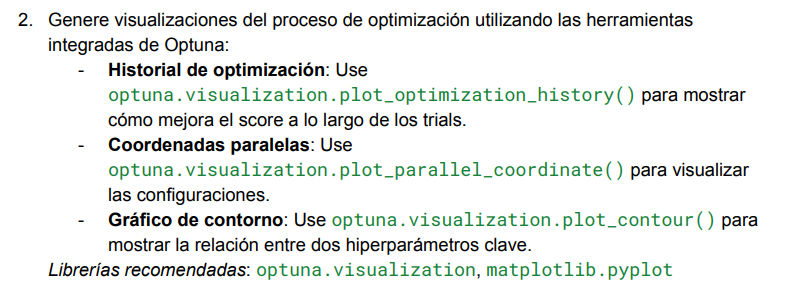

In [ ]:
import optuna.visualization as vis

# 1) Historial de optimizacion: como mejora la accuracy a lo largo de los trials
fig_historial = vis.plot_optimization_history(estudio)
fig_historial.update_layout(title='Historial de optimizacion (accuracy CV por trial)')
fig_historial.show()

# 2) Coordenadas paralelas: una linea por trial, color = accuracy
fig_paralelas = vis.plot_parallel_coordinate(
    estudio, params=['n_estimators', 'max_depth', 'min_samples_split'])
fig_paralelas.update_layout(title='Coordenadas paralelas de los trials completos')
fig_paralelas.show()

# 3) Contorno: relacion entre dos hiperparametros clave
fig_contorno = vis.plot_contour(estudio, params=['max_depth', 'n_estimators'])
fig_contorno.update_layout(title='Accuracy esperada segun max_depth y n_estimators')
fig_contorno.show()


In [ ]:
import optuna

importancias = optuna.importance.get_param_importances(estudio)
for nombre, valor in importancias.items():
    print(f'{nombre}: {valor:.2f}')


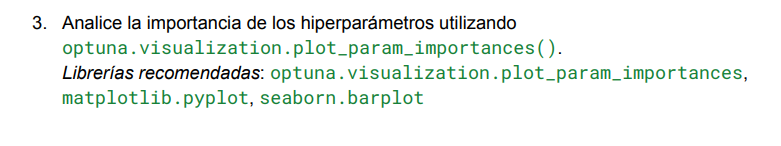

In [ ]:
import optuna
import optuna.visualization as vis

# Evaluador con semilla fija: fANOVA ajusta un Random Forest y sin semilla el resultado varia entre corridas
evaluador = optuna.importance.FanovaImportanceEvaluator(seed=SEMILLA)

# 1) Grafico propio de Optuna (consigna del inciso 3)
fig_importancias = vis.plot_param_importances(estudio, evaluator=evaluador)
fig_importancias.update_layout(title='Importancia de los hiperparametros (fANOVA)')
fig_importancias.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importancias = optuna.importance.get_param_importances(estudio, evaluator=evaluador) #ya viene ordenado de mayor a menor
tabla_imp = pd.DataFrame({'Hiperparametro': list(importancias.keys()),
                          'Importancia': list(importancias.values())})

plt.figure(figsize=(7, 3.5))
ax = sns.barplot(data=tabla_imp, x='Importancia', y='Hiperparametro', color='steelblue')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)   #valor numérico en cada barra
ax.set_title('Importancia de los hiperparametros (fANOVA)')
ax.set_xlabel('Fraccion de la variacion de accuracy explicada')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


# Ejercicio 3

##3.1

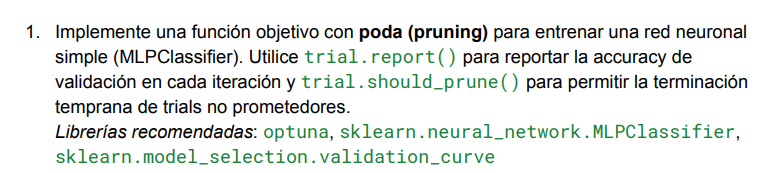

In [27]:
import optuna
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

#Separar entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

#Convertir cada imagen 28x28 en un vector de 784 características
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)


def objective(trial):

    #Planteamos los hiperparametros posibles para este trial
    hidden_layer_size = trial.suggest_int("hidden_layer_size", 10, 100)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    #Creamos el modelo
    model = MLPClassifier(
        hidden_layer_sizes=(hidden_layer_size,),
        learning_rate_init=learning_rate,
        max_iter=1,
        random_state=42
    )

    n_epochs = 50

    #Entrenamos una época a la vez
    for epoch in range(n_epochs):

        model.partial_fit(X_train, y_train, classes=np.unique(y_train))

        y_pred = model.predict(X_val)
        score = accuracy_score(y_val, y_pred) #Accuracy en validacion

        #Reportar resultado a Optuna
        trial.report(score, epoch)

        #Verifica si hay que podar este trial
        if trial.should_prune():
            raise optuna.TrialPruned()

    return score


#Creamos el estudio
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())

#Ejecutarmos 20 trials
study.optimize(objective, n_trials=20)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


##3.2

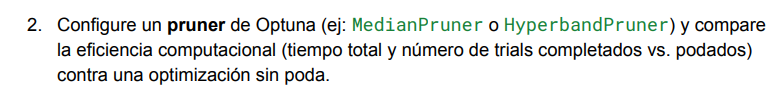

In [28]:
import optuna
import time
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

#Optimización sin poda

study_no_pruning = optuna.create_study(direction="maximize", pruner=optuna.pruners.NopPruner())

start_time = time.time()

study_no_pruning.optimize(objective,n_trials=20)

time_no_pruning = time.time() - start_time

In [29]:
#Optimización con poda

study_pruning = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())

start_time = time.time()

study_pruning.optimize(objective,n_trials=20)

time_pruning = time.time() - start_time

In [30]:
from optuna.trial import TrialState

completed_no_pruning = sum(
    trial.state == TrialState.COMPLETE
    for trial in study_no_pruning.trials
)

pruned_no_pruning = sum(
    trial.state == TrialState.PRUNED
    for trial in study_no_pruning.trials
)

completed_pruning = sum(
    trial.state == TrialState.COMPLETE
    for trial in study_pruning.trials
)

pruned_pruning = sum(
    trial.state == TrialState.PRUNED
    for trial in study_pruning.trials
)

In [31]:
print("Sin poda")
print(f"Tiempo total: {time_no_pruning:.2f} segundos")
print(f"Trials completados: {completed_no_pruning}")
print(f"Trials podados: {pruned_no_pruning}")

print("\nCon poda")
print(f"Tiempo total: {time_pruning:.2f} segundos")
print(f"Trials completados: {completed_pruning}")
print(f"Trials podados: {pruned_pruning}")

Sin poda
Tiempo total: 1869.28 segundos
Trials completados: 20
Trials podados: 0

Con poda
Tiempo total: 877.62 segundos
Trials completados: 10
Trials podados: 10


##3.3

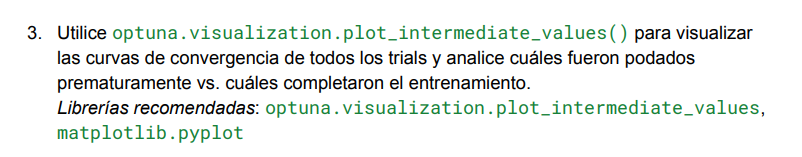

In [32]:
fig = optuna.visualization.plot_intermediate_values(
    study_pruning
)

fig.update_layout(
    title="Convergencia de los trials con poda",
    xaxis_title="Época",
    yaxis_title="Accuracy de validación",
    template="plotly_white",
    width=900,
    height=550,
    font=dict(size=13),
    title_font=dict(size=20)
)

fig.show()

#Parte 2

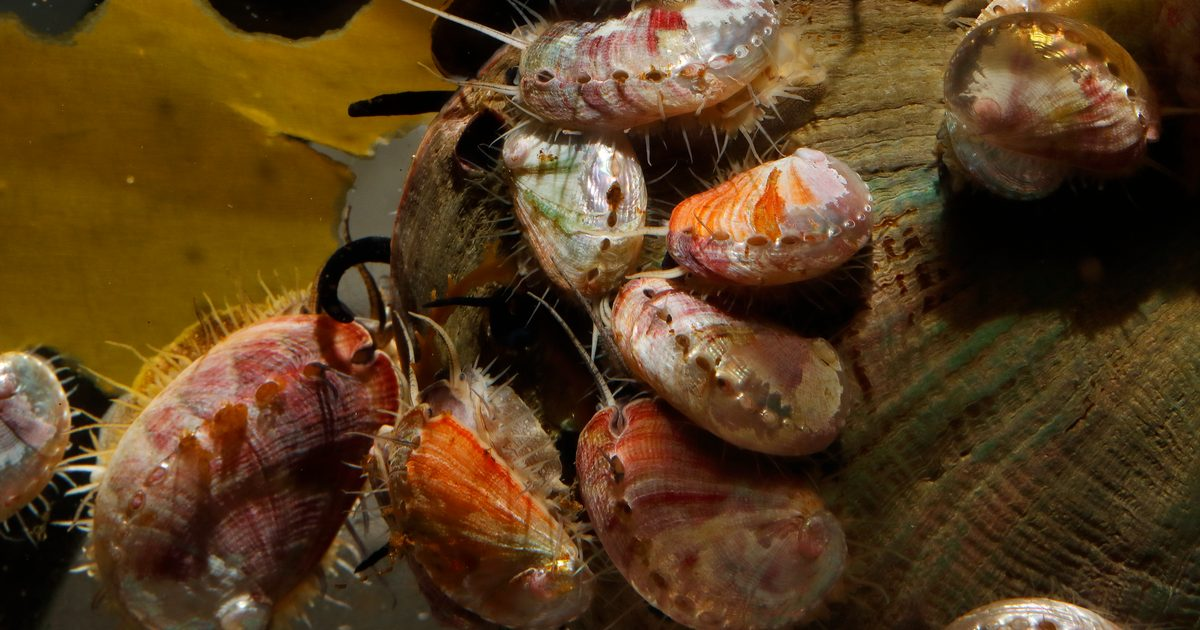

El dataset Abalone está compuesto por nueve variables. La variable `Sex` es categórica y representa el sexo del abalón, pudiendo tomar los valores M (macho), F (hembra) e I (indeterminado). Las variables `Length`, `Diameter` y `Height` corresponden a diferentes medidas físicas de la concha. Por otro lado, `WholeWeight` representa el peso total del abalón, mientras que `ShuckedWeight` corresponde al peso de la carne una vez retirada de la concha. `VisceraWeight` representa el peso de las vísceras y `ShellWeight` el peso de la concha seca. Finalmente, `Rings` indica la cantidad de anillos presentes en la concha y constituye la variable objetivo del problema, ya que se utiliza para estimar la edad del abalón.


##eda

In [35]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
column_names = [ "Sex", "Length", "Diameter", "Height", "WholeWeight", "ShuckedWeight", "VisceraWeight", "ShellWeight", "Rings" ]
abalone = pd.read_csv(url, names=column_names)

Dimensiones del dataset:
(4177, 9)

Información de las variables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sex            4177 non-null   object 
 1   Length         4177 non-null   float64
 2   Diameter       4177 non-null   float64
 3   Height         4177 non-null   float64
 4   WholeWeight    4177 non-null   float64
 5   ShuckedWeight  4177 non-null   float64
 6   VisceraWeight  4177 non-null   float64
 7   ShellWeight    4177 non-null   float64
 8   Rings          4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB
None

Valores faltantes por variable:
Sex              0
Length           0
Diameter         0
Height           0
WholeWeight      0
ShuckedWeight    0
VisceraWeight    0
ShellWeight      0
Rings            0
dtype: int64

Cantidad total de valores faltantes:
0

Estadísticas desc

,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


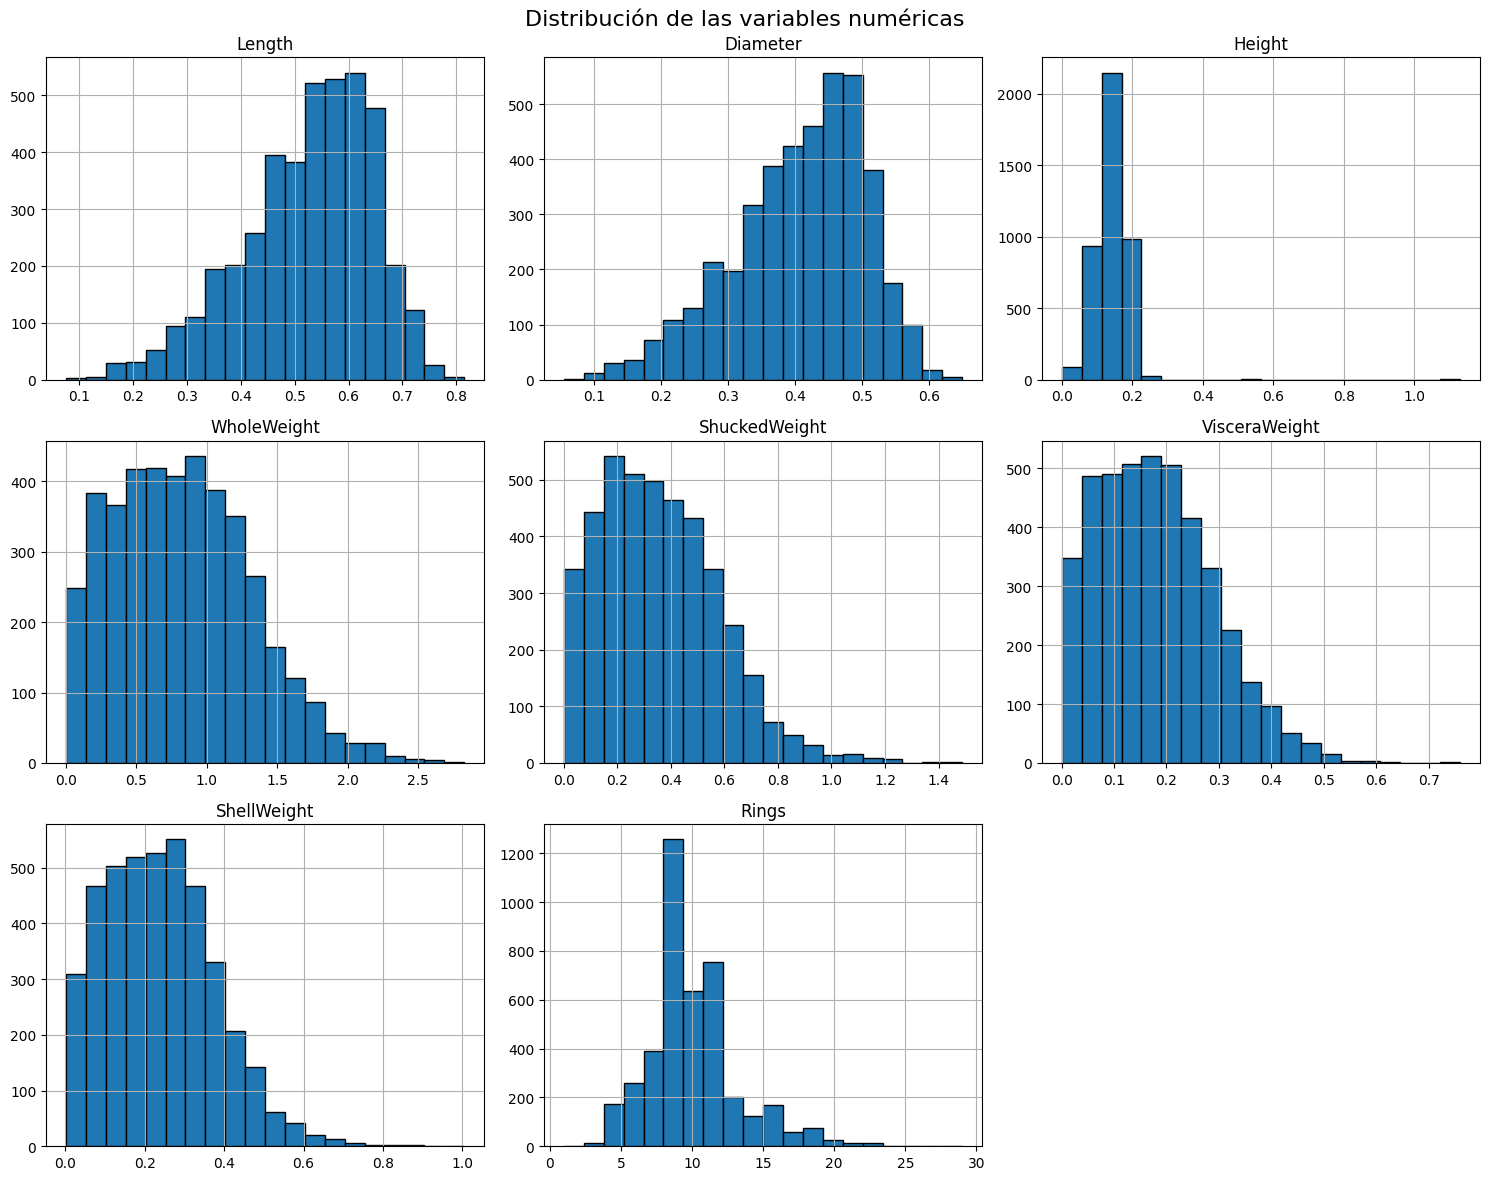

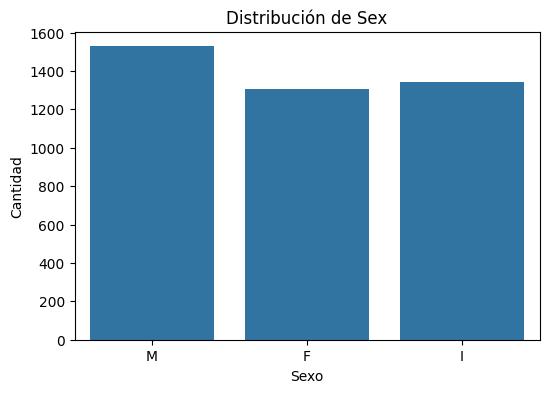


Distribución porcentual de Sex:
Sex
M    36.581278
I    32.128322
F    31.290400
Name: proportion, dtype: float64


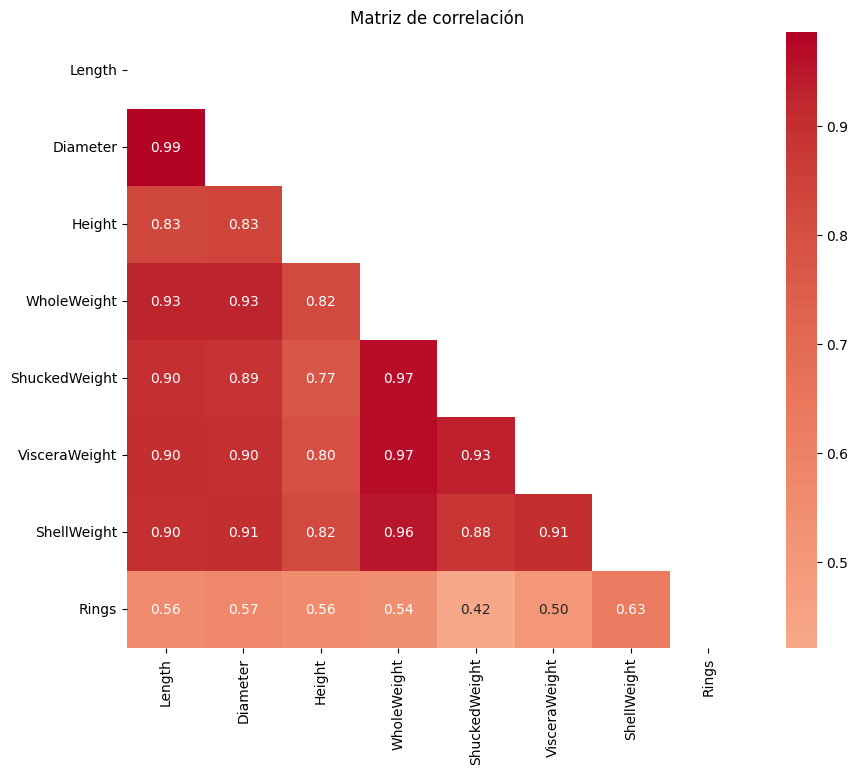

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("Dimensiones del dataset:")
print(abalone.shape)

print("\nInformación de las variables:")
print(abalone.info())

print("\nValores faltantes por variable:")
print(abalone.isnull().sum())

print("\nCantidad total de valores faltantes:")
print(abalone.isnull().sum().sum())


#estadisticas descriptivas
print("\nEstadísticas descriptivas:")
display(abalone.describe())

#distribucion de variables

# Variables numéricas
variables_numericas = abalone.select_dtypes(include="number").columns

abalone[variables_numericas].hist(
    bins=20,
    figsize=(15, 12),
    edgecolor="black"
)

plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()



plt.figure(figsize=(6, 4))

sns.countplot(data=abalone, x="Sex")

plt.title("Distribución de Sex")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.show()


# También podemos ver los porcentajes
print("\nDistribución porcentual de Sex:")
print(abalone["Sex"].value_counts(normalize=True) * 100)

#correlaciones

correlacion = abalone[variables_numericas].corr()
mask = np.triu(np.ones_like(correlacion, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacion,
    annot=True,
    mask=mask,
    cmap="coolwarm",

    fmt=".2f",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

La variable objetivo Rings presenta valores enteros en un rango aproximado de 1 a 29 anillos, por lo que los errores del modelo deben interpretarse en relación con esta escala.

# Ejercicio 4

#4.1
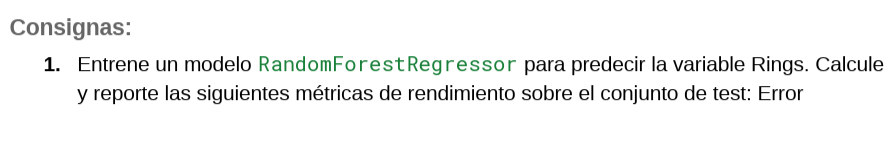
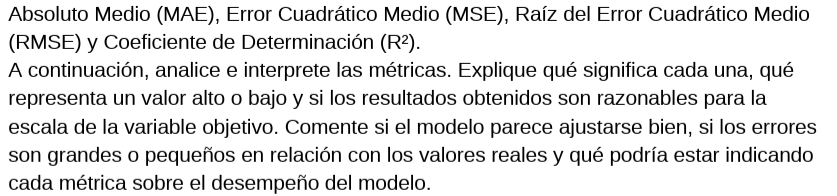

In [37]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

abalone_encoded = pd.get_dummies(abalone, columns=["Sex"], drop_first=True)

# Dividimos en Características (X) y Objetivo (y - Rings)
X = abalone_encoded.drop(columns=["Rings"])
y = abalone_encoded["Rings"]

# 2. Separar en conjuntos de entrenamiento (train) y prueba (test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

#Métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"MSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

MAE:  1.587
MSE:  5.108
RMSE: 2.260
R²:   0.528


El modelo Random Forest obtuvo un MAE de **1,587**, lo que significa que, en promedio, las predicciones se alejan aproximadamente **1,6 anillos** del valor real. Dado que la variable objetivo `Rings` presenta valores aproximadamente entre **1 y 29 anillos**, este error puede considerarse moderado y razonable para la escala del problema. Un valor de MAE más bajo indicaría un mejor desempeño, mientras que un valor más alto representaría errores mayores en las predicciones.

El **MSE** obtenido fue de **5,108**. Esta métrica calcula el promedio de los errores al cuadrado, por lo que penaliza especialmente los errores grandes. Por este motivo, un valor alto de MSE puede indicar la presencia de algunas predicciones con errores importantes. Sin embargo, como el MSE queda expresado en unidades cuadradas, resulta más intuitivo analizar el RMSE.

El **RMSE** fue de **2,260**, por lo que el error se encuentra aproximadamente en el orden de 2,3 anillos, dando un mayor peso a los errores grandes. El hecho de que el RMSE sea superior al MAE (2,260 frente a 1,587) indica que existen algunos errores relativamente grandes que tienen una influencia importante sobre el desempeño del modelo. Aun así, este valor resulta razonable considerando el rango de la variable objetivo.

Finalmente, el **R² fue de 0,528**, lo que indica que el modelo logra explicar aproximadamente el **52,8 % de la variabilidad observada en la cantidad de anillos**. El valor ideal de R² es 1, mientras que un valor cercano a 0 indica que el modelo explica muy poco de la variabilidad respecto de utilizar simplemente la media como predicción. En este caso, el valor obtenido representa un ajuste **moderado**: el modelo captura una parte importante de las relaciones presentes en los datos, pero todavía existe una proporción considerable de variabilidad que no logra explicar.

En conjunto, las métricas indican que el modelo presenta un **desempeño razonable, aunque no excelente**. Los errores de predicción son relativamente moderados respecto de la escala de `Rings`, pero la diferencia entre MAE y RMSE muestra que existen algunos errores mayores. Además, el R² de 0,528 indica que aproximadamente la mitad de la variabilidad de la variable objetivo queda explicada por el modelo, mientras que la otra mitad podría estar relacionada con características no incluidas en el conjunto de datos, variabilidad propia de los individuos u otros factores que el modelo no logra capturar. Por lo tanto, el modelo puede considerarse **útil como aproximación para predecir la cantidad de anillos, pero presenta margen de mejora**.


#4.2
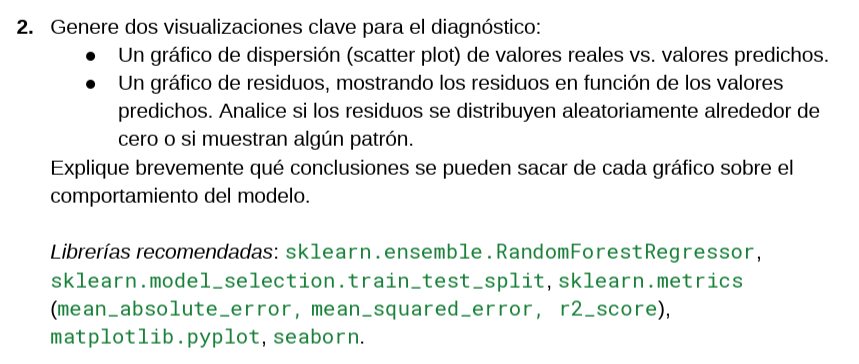

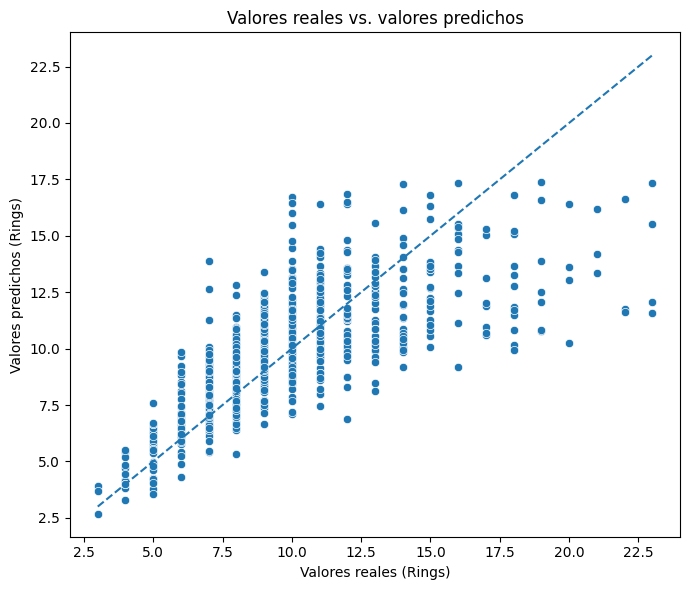

In [38]:
#Scatter plot: valores reales vs. predichos
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

# Línea de predicción perfecta
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Valores reales (Rings)")
plt.ylabel("Valores predichos (Rings)")
plt.title("Valores reales vs. valores predichos")
plt.tight_layout()
plt.show()

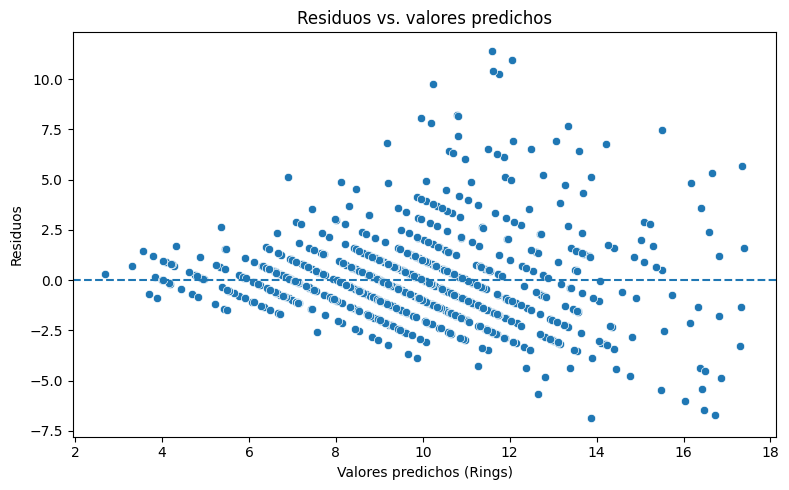

In [39]:
#residuos
residuos = y_test - y_pred
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=residuos
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Valores predichos (Rings)")
plt.ylabel("Residuos")
plt.title("Residuos vs. valores predichos")
plt.tight_layout()
plt.show()

Se observa que la dispersión de las predicciones no es constante para todos los valores de `Rings`. Para valores bajos, las predicciones se encuentran relativamente concentradas, mientras que para valores más altos presentan una dispersión considerablemente mayor. Esto indica que la magnitud de los errores varía según el nivel de la variable objetivo, lo que puede ser indicativo de heterocedasticidad. En otras palabras, el modelo presenta errores más variables para determinados rangos de `Rings`.


#Ejercicio 5

##5.1
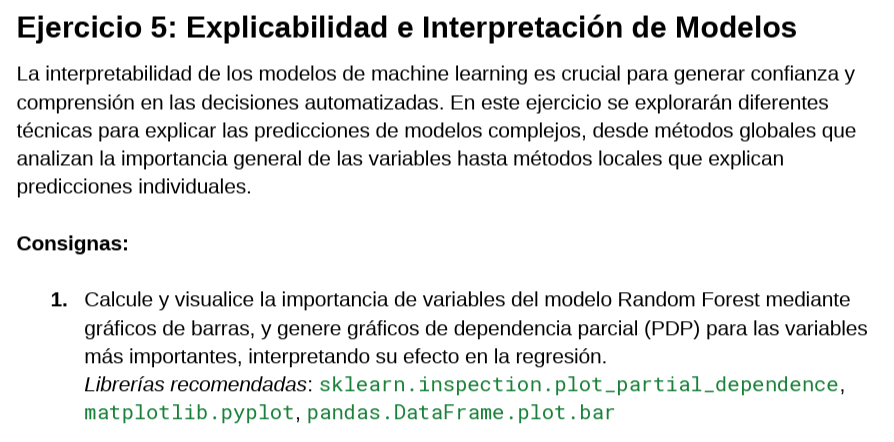

##5.2
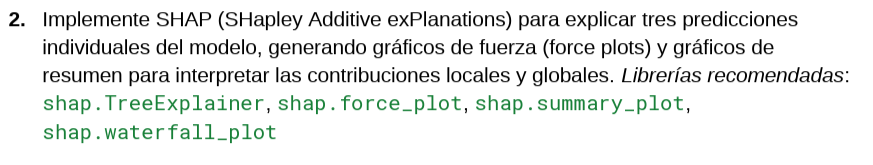

##5.3
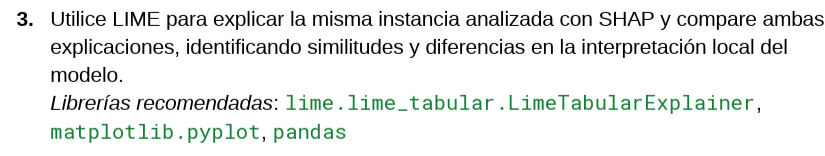

#Ejercicio 6